In [6]:
import numpy as np
import pandas as pd
import random
import time
from rapidfuzz import process, fuzz, distance
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import spoa 

# --- 2. DATA GENERATION & UTILS ---
def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# (Generating fresh data to ensure variables exist for the loop below)
n_items = 100_000 
pool_bc = [gen_dna(12) for _ in range(n_items)]
pool_ins = [gen_dna(50) for _ in range(n_items)]
n_repeat_bc = 500
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]

data = []
for i in range(len(pool_bc)):
     n_reads = random.randint(1, 6) 
     for _ in range(n_reads):
         data.append({
             "ID": i,
             "Barcode": mutate_sequence(pool_bc[i], 0.05), 
             "Insert": mutate_sequence(pool_ins[i], 0.05)
         })

df = pd.DataFrame(data)

barcode_counts = df['Barcode'].value_counts()
all_barcodes = np.array(barcode_counts.index.tolist())

In [7]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.manifold import spectral_embedding
from rapidfuzz import process, fuzz
import spoa 
from typing import List

# --- 1. CONFIGURATION ---
seed = 42
random.seed(seed)
np.random.seed(seed)
VERBOSE_LEVEL = 1 



# Generate Mock Data if running standalone
if 'df' not in locals():
    print("Generating Mock Data...")
    barcodes = [gen_dna(10) for _ in range(5)]
    data = []
    for i, bc in enumerate(barcodes):
        # Create 3 distinct clusters per barcode to test spectral
        inserts = [gen_dna(20) for _ in range(3)]
        for ins_idx, ins in enumerate(inserts):
            for _ in range(30):
                data.append({'Barcode': mutate_sequence(bc, 0.05), 
                             'Insert': mutate_sequence(ins, 0.10), 
                             'ID': f"Grp{i}_C{ins_idx}_{random.randint(0,999)}"}) # Added random ID suffix
    df = pd.DataFrame(data)
    barcode_counts = df['Barcode'].value_counts()
    all_barcodes = df['Barcode'].unique()
    print("Mock Data Generated.\n")

# --- 3. CORE ALGORITHM FUNCTIONS ---

def encode_msa(msa_strings, alphabet="ACGTN-"):
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    max_len = max(len(s) for s in msa_strings)
    msa_padded = [s.ljust(max_len, '-') for s in msa_strings]
    msa_array = np.array([list(seq) for seq in msa_padded])
    N, L = msa_array.shape
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
    return msa_int, len(alphabet)

def get_marginals(msa_int, vocab_size):
    one_hot = np.eye(vocab_size)[msa_int]
    P_i = one_hot.mean(axis=0)
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    N, L, A = one_hot.shape
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    return mi_matrix.sum(axis=(1, 3))

def validate_split_percentile(cluster_A_indices, cluster_B_indices, all_df, local_df,
                              percentile_th=5, min_dist_auto_split=15, min_length_auto_split=30, 
                              n_background_target=1000, verbose=0):
    inserts_A = local_df.loc[cluster_A_indices, 'Insert'].tolist()
    inserts_B = local_df.loc[cluster_B_indices, 'Insert'].tolist()
    
    if not inserts_A or not inserts_B: return False

    subset_A = inserts_A[:100]
    subset_B = inserts_B[:100]
    
    # Calculate Distances (100 - Similarity)
    signal_dist_raw = 100 - process.cdist(subset_A, subset_B, scorer=fuzz.ratio)
    signal_dist = signal_dist_raw.mean()
    
    # --- NEW LOGIC: AUTO-ACCEPT ---
    seq_len = len(subset_A[0]) if len(subset_A) > 0 else 0

    if verbose >= 3:
        print(f"signal distance is {signal_dist}")
    
    if signal_dist > min_dist_auto_split and seq_len > min_length_auto_split:  # don't autosplit on short seqs
        if verbose >= 2:
            print(f"      [Val] Auto-Accept: Signal dist {signal_dist:.1f} < {min_dist_auto_split} & Length {seq_len} > {min_length_auto_split}")
        return True
    # ------------------------------
    
    remaining_df = all_df.drop(local_df.index, errors='ignore')
    n_background = min(n_background_target, len(remaining_df))
    
    if n_background < 10: 
        return signal_dist > 15.0

    random_inserts = remaining_df.sample(n=n_background)['Insert'].tolist()
    bg_dists_A = 100 - process.cdist(subset_A, random_inserts, scorer=fuzz.ratio)
    bg_dists_B = 100 - process.cdist(subset_B, random_inserts, scorer=fuzz.ratio)
    
    threshold_value = (np.percentile(bg_dists_A, percentile_th) + np.percentile(bg_dists_B, percentile_th))/2
    is_valid = signal_dist > threshold_value 
    
    if verbose >= 2:
        print(f"      [Val] Signal: {signal_dist:.1f} | BG Thresh: {threshold_value:.1f} | Valid: {is_valid}")

    if verbose >= 3:
        print(signal_dist_raw)
        
    return is_valid

def get_elbow_columns(mi_matrix, exclusion_distance=5, verbose=0):
    L = mi_matrix.shape[0]
    mask = np.triu(np.ones((L, L), dtype=bool), k=exclusion_distance + 1)
    rows, cols = np.where(mask)
    scores = mi_matrix[rows, cols]
    
    if len(scores) == 0: return np.array([])

    # 1. Sort Descending
    sorted_indices = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_indices]
    
    # 2. Determine "Signal End" (Noise Floor Truncation)
    # We stop analyzing where the score drops below the bottom 25% percentile
    noise_floor = np.percentile(scores, 25)
    
    # Keep points strictly ABOVE noise floor for the shape analysis
    # (But keep at least 5 points to allow for geometry, unless total is small)
    valid_mask = sorted_scores > noise_floor
    n_signal_points = np.sum(valid_mask)
    
    # Safety: if signal is super short, take at least top 10% or min 5
    min_points = min(len(sorted_scores), 5)
    cutoff_idx = max(n_signal_points, min_points)
    
    # 3. Truncate for Geometry Calculation
    # We only look for the elbow within the "Signal" region
    curve_y = sorted_scores[:cutoff_idx]
    n_points = len(curve_y)
    
    if n_points < 3:
        # Fallback for tiny signals
        return np.unique(np.concatenate([rows[sorted_indices[:n_points]], cols[sorted_indices[:n_points]]]))

    # 4. Standard Kneedle on Truncated Curve
    x_norm = np.linspace(0, 1, n_points)
    y_norm = (curve_y - curve_y.min()) / (curve_y.max() - curve_y.min() + 1e-9)
    
    # Line from First Point (0, 1) to Last Signal Point (1, 0)
    line_vec = np.array([1.0, -1.0]) # Direction vector (x=1-0, y=0-1)
    line_vec = line_vec / np.linalg.norm(line_vec)
    
    # Vectors from start (0, 1) to all points
    vec_from_start = np.stack([x_norm, y_norm - 1.0], axis=1)
    
    # Cross product (2D) to find distance
    distances = np.abs(vec_from_start[:, 0] * line_vec[1] - vec_from_start[:, 1] * line_vec[0])
    
    # 5. Select
    elbow_idx = np.argmax(distances)
    
    # If the plateau is perfectly flat, elbow_idx might be 0. 
    # In that case, we likely want the whole plateau, not just index 0.
    # We check if the point at elbow_idx is significantly higher than end.
    if elbow_idx == 0:
        # Heuristic: If index 0 is picked, but index 1 is very close in value, walk forward
        # This handles the "perfect plateau" case
        for i in range(1, n_points - 1):
            if curve_y[i] >= (curve_y[0] * 0.95): # Still within 5% of max
                elbow_idx = i
            else:
                break

    n_selected = elbow_idx + 1 # +1 because index is 0-based
    
    # --- Debug Plot (Only if Verbose) ---
    if verbose >= 3:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6, 3))
        plt.plot(range(n_points), curve_y, '-o', markersize=3, label='Signal Curve')
        plt.axvline(elbow_idx, color='r', linestyle='--', label=f'Elbow (k={n_selected})')
        plt.axhline(noise_floor, color='k', linestyle=':', alpha=0.5, label='Noise Floor')
        plt.title(f"Elbow Analysis (Selecting {n_selected} cols)")
        plt.legend()
        plt.show()

    selected_indices = sorted_indices[:n_selected]

    selected_columns = np.unique(np.concatenate([rows[selected_indices], cols[selected_indices]]))
    
    if verbose >= 3:
        print(f"selected MSA columns: {selected_columns}")
    return selected_columns
    
# --- PLOTTING FUNCTIONS ---

def plot_msa_and_pca(msa_int, sub_df_indices, top_cols, vocab_size, title):
    """Plots final result."""
    msa_subset = msa_int[:, top_cols]
    read_indices = sub_df_indices.tolist()
    N = len(read_indices)
    
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features = subset_one_hot.reshape(N, -1)
    pca = PCA(n_components=min(N, 2), whiten=True)
    coords = pca.fit_transform(features)
    
    fig = plt.figure(figsize=(10, 0.4 * N + 5)) 
    gs = gridspec.GridSpec(2, 2, height_ratios=[max(1, 0.4*N), 4])
    
    ax_msa = fig.add_subplot(gs[0, :])
    cmap_msa = colors.ListedColormap(['#00B050', '#0070C0', '#FFC000', '#FF0000', '#A0A0A0', '#F0F0F0'][:vocab_size])
    ax_msa.imshow(msa_subset, aspect='auto', cmap=cmap_msa, interpolation='nearest', vmin=0, vmax=vocab_size-1)
    ax_msa.set_title(title)


    ax_pca = fig.add_subplot(gs[1, :])
    if coords.shape[1] >= 2:
        ax_pca.scatter(coords[:, 0], coords[:, 1], alpha=0.7, edgecolors='k')
        ax_pca.set_xlabel("PC1")
        ax_pca.set_ylabel("PC2")
    else:
        ax_pca.scatter(coords[:, 0], np.zeros(N), alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_split_proposal(msa_int, top_cols, vocab_size, parent_indices_int, mask_a, mask_b, ids_list, title):
    """
    Visualizes a specific split proposal by running local PCA on only the parent cluster points.
    ANNOTATES with IDs.
    """
    if len(parent_indices_int) < 3: return

    # 1. Extract features ONLY for the parent cluster
    msa_subset = msa_int[parent_indices_int][:, top_cols]
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features = subset_one_hot.reshape(len(parent_indices_int), -1)
    
    # 2. Run Local PCA (2D)
    pca = PCA(n_components=2, whiten=True)
    coords = pca.fit_transform(features)
    
    # 3. Determine Colors
    color_labels = []
    for idx in parent_indices_int:
        if mask_a[idx]: color_labels.append('red')
        elif mask_b[idx]: color_labels.append('blue')
        else: color_labels.append('lightgray')
    
    # 4. Calculate Jitter ONCE so we can apply it to both dots and text
    jitter_x = np.random.normal(0, 0.05, len(coords))
    jitter_y = np.random.normal(0, 0.05, len(coords))
    
    final_x = coords[:, 0] + jitter_x
    final_y = coords[:, 1] + jitter_y

    # 5. Plot Points
    plt.figure(figsize=(10, 8)) # Made figure larger to accommodate text
    plt.scatter(final_x, final_y, c=color_labels, edgecolor='k', alpha=0.6, s=60)
    
    # 6. Plot Text Labels (IDs)
    # We zip coordinate + ID. ids_list corresponds to parent_indices_int order
    for x, y, uid in zip(final_x, final_y, ids_list):
        plt.text(x, y, str(uid), fontsize=8, alpha=0.8)

    # Create manual legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Proposed A'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Proposed B')
    ]
    plt.legend(handles=legend_elements)
    plt.title(f"{title}\nLocal PCA of Parent Cluster")
    plt.xlabel("Local PC1")
    plt.ylabel("Local PC2")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# --- 4. CLUSTERING ALGORITHM ---

def iterative_hamming_driver(sub_df, all_df, barcode_target, percentile_th, verbose=0):
    
    # A. PREP
    if len(sub_df) < 3: 
        if verbose >= 3: print(f"[DEBUG] Input too small (N={len(sub_df)}). Returning original.")
        return [sub_df]

    barcodes = sub_df['Barcode'].tolist()
    _, msa_barcodes = spoa.poa(barcodes, algorithm=2) 
    inserts = sub_df['Insert'].tolist()
    _, msa_inserts = spoa.poa(inserts, algorithm=2)
    
    msa_strings = [b + "--------" + i for b, i in zip(msa_barcodes, msa_inserts)]
    msa_int, vocab_size = encode_msa(msa_strings)
    
    _, P_i = get_marginals(msa_int, vocab_size)
    one_hot = np.eye(vocab_size)[msa_int]
    mi_matrix = compute_mi_scores(one_hot, P_i)

    if verbose >= 3:
        
        for s in msa_strings:
            print(s)
            
        plt.figure(figsize=(8, 6))
        # Mask upper triangle including diagonal (k=0)
        masked_mi = np.ma.masked_where(np.triu(np.ones_like(mi_matrix), k=0), mi_matrix)
        
        # origin='lower' moves (0,0) to the bottom-left corner
        plt.imshow(masked_mi, aspect='auto', interpolation='nearest', 
                   cmap='viridis', origin='lower')
        
        plt.colorbar(label='MI Score')
        plt.title("Mutual Information (Lower Triangle)")
        plt.show()
    
    top_cols = get_elbow_columns(mi_matrix, exclusion_distance=5, verbose=verbose)
    
    if verbose >= 3:
        print(f"[DEBUG] MI Analysis: Selected {len(top_cols)} columns based on Elbow Method.")
        # print(f"[DEBUG] Top Columns indices: {top_cols}")

    if len(top_cols) == 0:
        if verbose >= 3: print("[DEBUG] No informative columns found. Aborting.")
        return [sub_df]

    # B. DATA SUBSET
    msa_subset = msa_int[:, top_cols]

    np.save("/Users/ogw/Downloads/msa.npy", msa_subset)

    # C. PCA (VISUALIZATION ONLY)
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features_onehot = subset_one_hot.reshape(len(sub_df), -1)
    
    n_samples = len(sub_df)
    n_components = 0.95
    if n_samples < 5: n_components = min(n_samples, 2)
        
    pca = PCA(n_components=n_components, whiten=True)
    coords = pca.fit_transform(features_onehot)

    # D. ITERATIVE EXPANSION
    current_k = 1
    current_labels = np.zeros(len(sub_df), dtype=int)

    clustering_accepted = True
    max_k = min(len(sub_df), 20)
    
    if verbose >= 1:
        print(f"  -> Hamming Driver: Starting at k=1")

    while clustering_accepted and current_k < max_k:
        next_k = current_k + 1
        
        if verbose >= 3: 
            print(f"\n[DEBUG] --- Iteration k={current_k} -> k={next_k} ---")
            print(f"[DEBUG] Running AgglomerativeClustering (Hamming/Average)...")

        try:
            # 1. Compute Hamming distance matrix (0.0 = identical, 1.0 = different)
            dist_matrix = pairwise_distances(msa_subset, metric='hamming')
            
            # 2. Convert to Affinity/Similarity matrix (1.0 = identical, 0.0 = different)
            affinity_matrix = 1 - dist_matrix
            
            # 3. Run Spectral Clustering on the affinity matrix
            model_next = SpectralClustering(
                n_clusters=next_k,
                affinity='precomputed',
                random_state=42  # Recommended to keep results deterministic
            )

            next_labels = model_next.fit_predict(affinity_matrix)
            print(msa_subset)
        except Exception as e:
            print(f"Clustering failed: {e}")
            break
        
        split_valid = False

            # E. RETURN
        if verbose >= 3:
        
            plot_msa_and_pca(
                msa_int, sub_df.index, top_cols, vocab_size,
                title=f"Hamming Final: k={current_k}"
            )
        
        # Check every cluster to see if it split
        unique_current_labels = np.unique(current_labels)
        if verbose >= 3: 
            print(f"[DEBUG] Existing clusters: {unique_current_labels}. Checking which one split...")

        for old_lbl in unique_current_labels:
            indices_old = np.where(current_labels == old_lbl)[0] 
            new_labels_in_group = next_labels[indices_old]
            unique_new = np.unique(new_labels_in_group)
            
            if len(unique_new) > 1:
                if verbose >= 3:
                    print(f"[DEBUG] >> Parent Cluster {old_lbl} (N={len(indices_old)}) split into: {unique_new}")

                counts = pd.Series(new_labels_in_group).value_counts()
                
                if verbose >= 3:
                    print(f"[DEBUG]    Split Sizes: {counts.to_dict()}")

                if len(counts) < 2: 
                    if verbose >= 3: print(f"[DEBUG]    Skipping: Not enough distinct sub-groups.")
                    continue
                
                lbl_a = counts.index[0]
                lbl_b = counts.index[1]
                
                mask_a = (next_labels == lbl_a) & (current_labels == old_lbl)
                mask_b = (next_labels == lbl_b) & (current_labels == old_lbl)
                
                idx_A = sub_df.index[mask_a]
                idx_B = sub_df.index[mask_b]
                
                if verbose >= 2:
                    print(f"    Checking split of Cluster {old_lbl} -> New sizes {len(idx_A)} vs {len(idx_B)}")

                # --- VISUALIZE SPLIT ---
                ids_for_plot = sub_df.iloc[indices_old]['ID'].tolist()
                
                if verbose >= 3: 
                    print(f"[DEBUG]    Generating plot for proposal...")
                    plot_split_proposal(msa_int, top_cols, vocab_size, 
                                        indices_old, mask_a, mask_b, 
                                        ids_list=ids_for_plot, 
                                        title=f"Hamming Split: k={current_k}->{next_k}")
                
                # --- VALIDATE ---
                if verbose >= 3: print(f"[DEBUG]    Calling validate_split_percentile()...")
                
                is_valid = validate_split_percentile(idx_A, idx_B, all_df, sub_df, 
                                                     percentile_th=percentile_th, verbose=verbose)
                
                if is_valid:
                    if verbose >= 3: print(f"[DEBUG]    >> VALIDATION PASSED. This split is real.")
                    split_valid = True
                    break 
                else:
                    if verbose >= 3: print(f"[DEBUG]    >> VALIDATION FAILED. Ignoring this split.")
            
            else:
                # This old cluster did not split
                # if verbose >= 3: print(f"[DEBUG] Parent Cluster {old_lbl} did not split.")
                pass

        if split_valid:
            if verbose >= 1: print(f"  -> Expansion to k={next_k} justified.")
            current_k = next_k
            current_labels = next_labels
        else:
            if verbose >= 1: print(f"  -> Expansion to k={next_k} rejected. Stopping.")
            if verbose >= 3: print(f"[DEBUG] No valid splits found among any parent clusters for k={next_k}.")
            clustering_accepted = False

        
    final_clusters = []
    for lbl in np.unique(current_labels):
        final_clusters.append(sub_df.iloc[np.where(current_labels == lbl)[0]])
    
    if verbose >= 3: print(f"[DEBUG] Returning {len(final_clusters)} final clusters.")
    return final_clusters

    


Processing Top Barcode #1: CGACTTTTCACT (Count: 14)
  > RapidFuzz gathered 32 reads
C-GAC-TTT-TGA-CT-----------ATGATTGCTAGTCT-ACGTTG-GTGACTT---CGA-G-CGG---CG-TG--AC--GG-A-GC-CT-GGA------------------------------------------------------------------------
C-GAC-TTT-TCA-CT-----------ATCATTGCTAGTCTGCCGTTG-GAGACTT---CGA-G-CGG---CG-TG--AC--GG-A-GC-CT-GGA------------------------------------------------------------------------
C-GAC-TTT-TCA-CT-----------ATGATTGCTA-TCT-ACGTTG-GTGACTTC--CGA-G-CGG---CG-TG--AC--GG-A-AC-CT-GGA------------------------------------------------------------------------
C-GAC-TTT-TCA-CT-----------ATGATTGCTAGTCT-ACGTTG-GTGACTT---CGA-G-CGG---CG-TG--AC--GG-A-GC-TT-GGA------------------------------------------------------------------------
C-GAC-TTT-TCA-CT-----------ATGATTGCTAATCT-ACGTTG-GTGACTT---CGA-G-CGG---CG-TG--AC--GG-A-GC-CT-GGA------------------------------------------------------------------------
C-GAC-TTT-TCA-CT-----------ATGATTGCTAGTCT-ACGTTG-GTGAC-T---CGA-G-CGG---

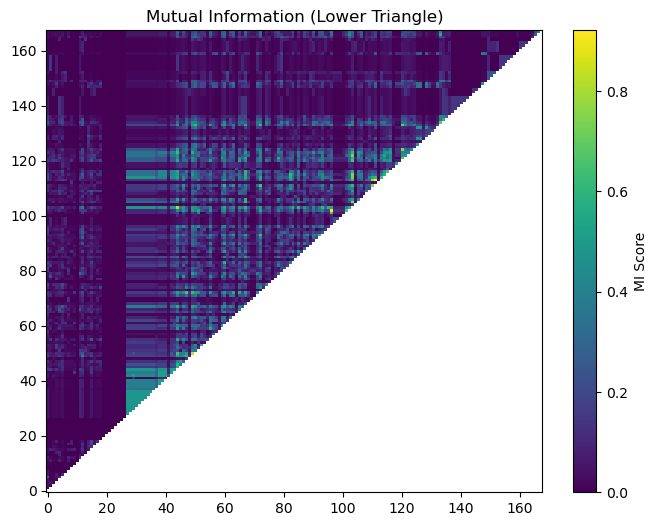

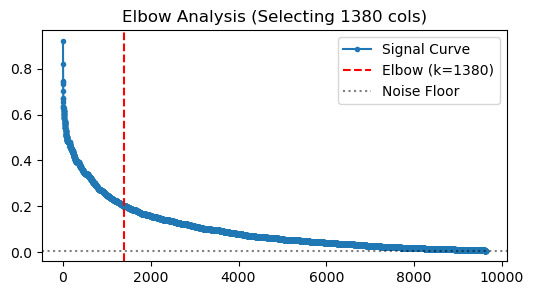

selected MSA columns: [  0   1   4   5  11  12  14  15  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  42  43  44  45  46  47  49  50  51  52  53  54  55  56
  57  59  60  61  62  63  64  65  66  67  68  71  72  74  75  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96 101
 102 103 105 106 107 108 109 110 111 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 128 129 132 133 134 135 136 147 148 149 152 159 165
 166 167]
[DEBUG] MI Analysis: Selected 110 columns based on Elbow Method.
  -> Hamming Driver: Starting at k=1

[DEBUG] --- Iteration k=1 -> k=2 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


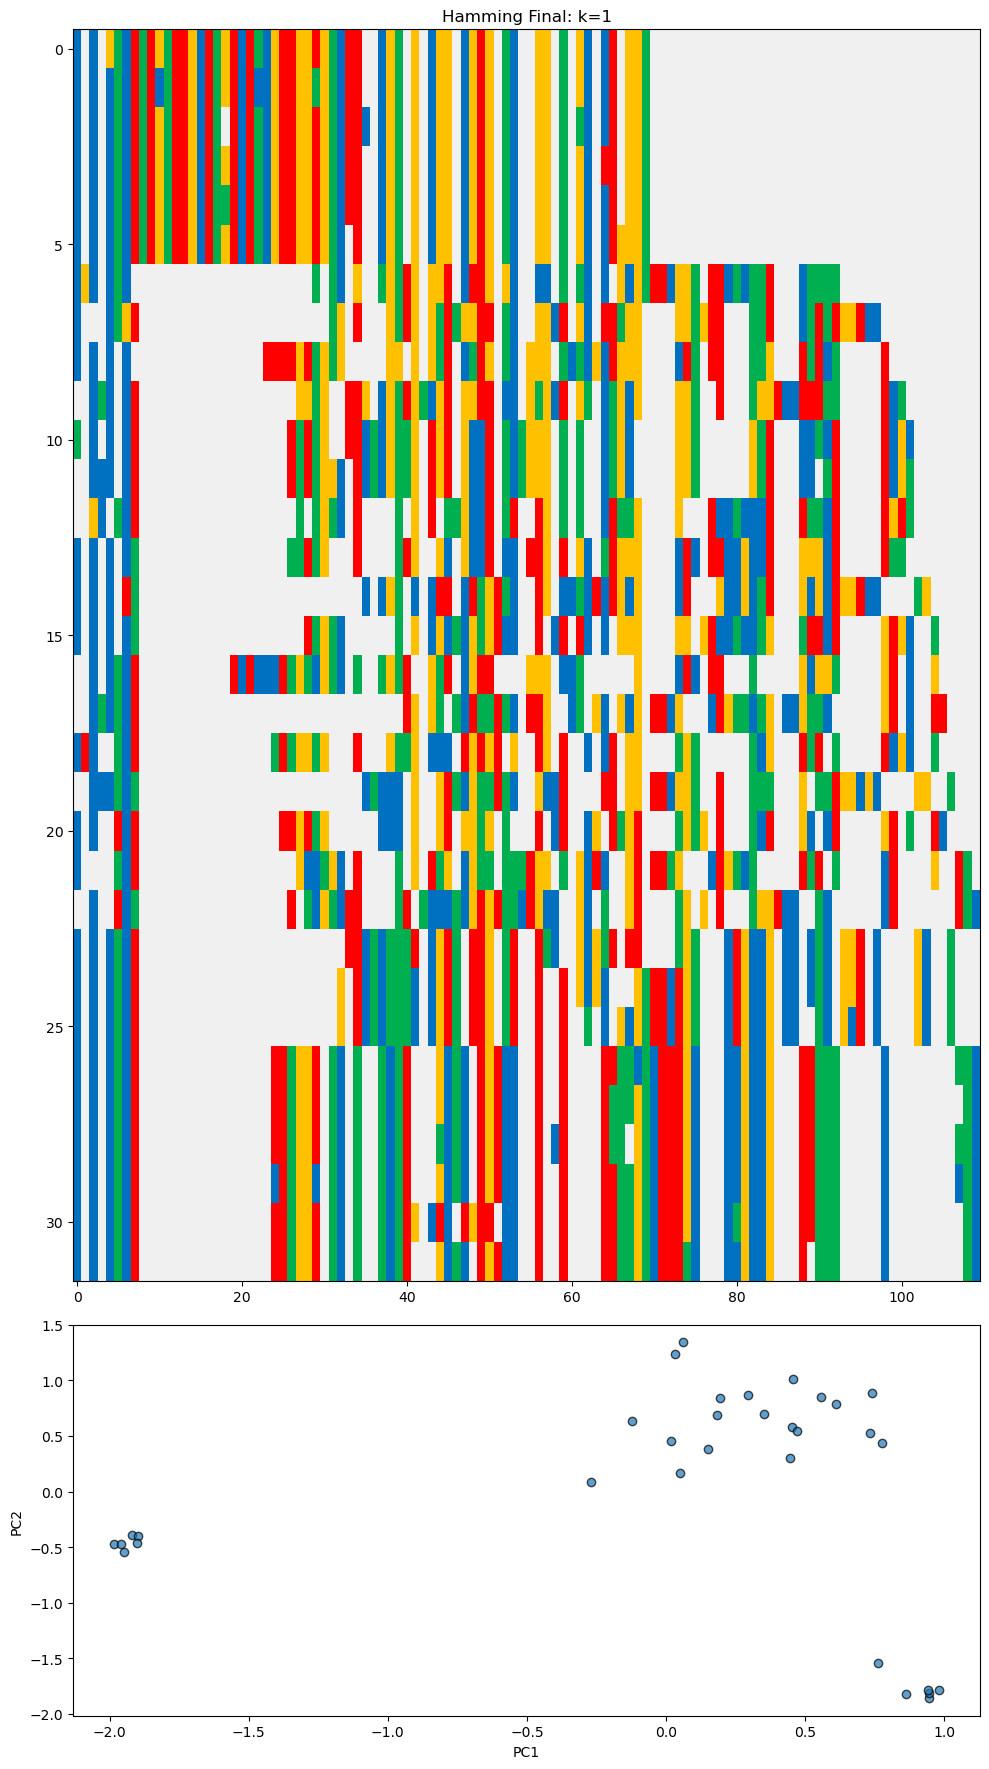

[DEBUG] Existing clusters: [0]. Checking which one split...
[DEBUG] >> Parent Cluster 0 (N=32) split into: [0 1]
[DEBUG]    Split Sizes: {1: 26, 0: 6}
    Checking split of Cluster 0 -> New sizes 26 vs 6
[DEBUG]    Generating plot for proposal...


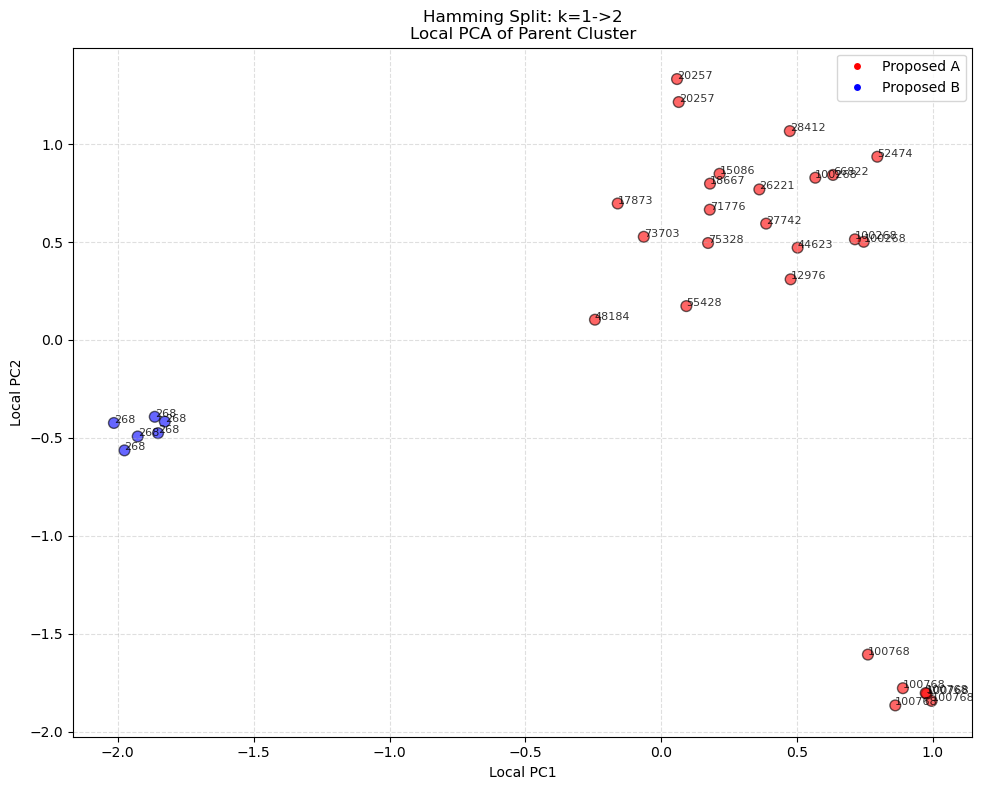

[DEBUG]    Calling validate_split_percentile()...
signal distance is 37.88077926635742
      [Val] Auto-Accept: Signal dist 37.9 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=2 justified.

[DEBUG] --- Iteration k=2 -> k=3 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


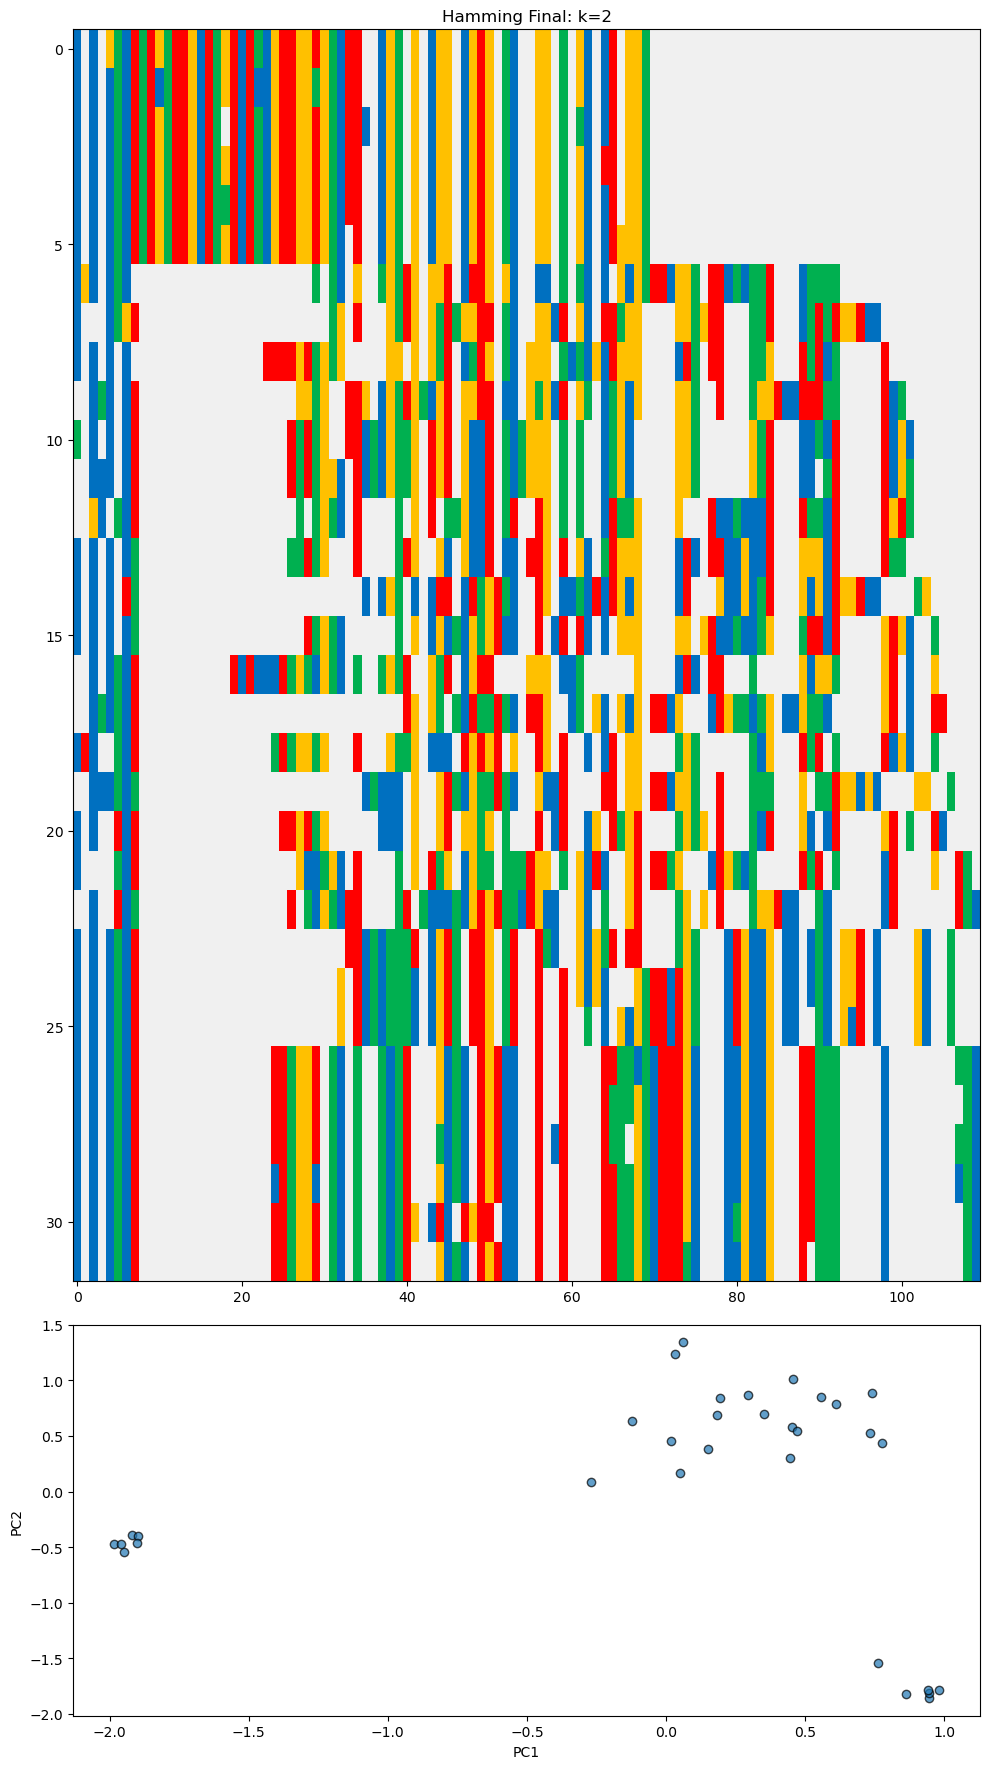

[DEBUG] Existing clusters: [0 1]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=26) split into: [1 2]
[DEBUG]    Split Sizes: {2: 20, 1: 6}
    Checking split of Cluster 1 -> New sizes 20 vs 6
[DEBUG]    Generating plot for proposal...


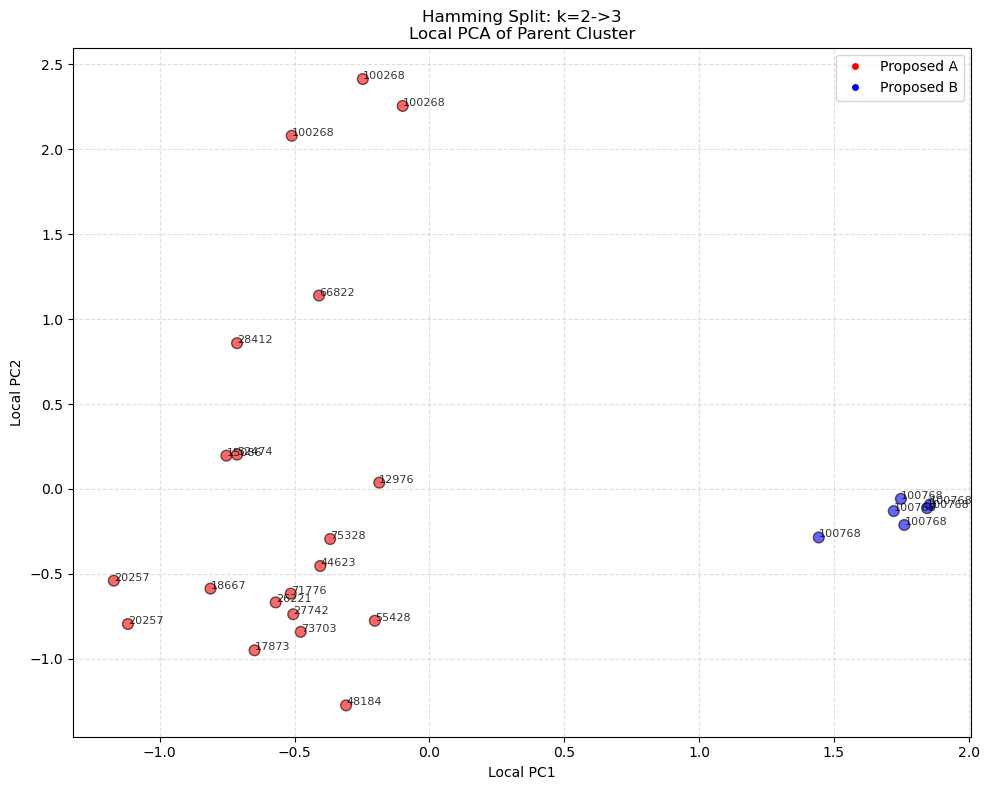

[DEBUG]    Calling validate_split_percentile()...
signal distance is 39.119808197021484
      [Val] Auto-Accept: Signal dist 39.1 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=3 justified.

[DEBUG] --- Iteration k=3 -> k=4 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


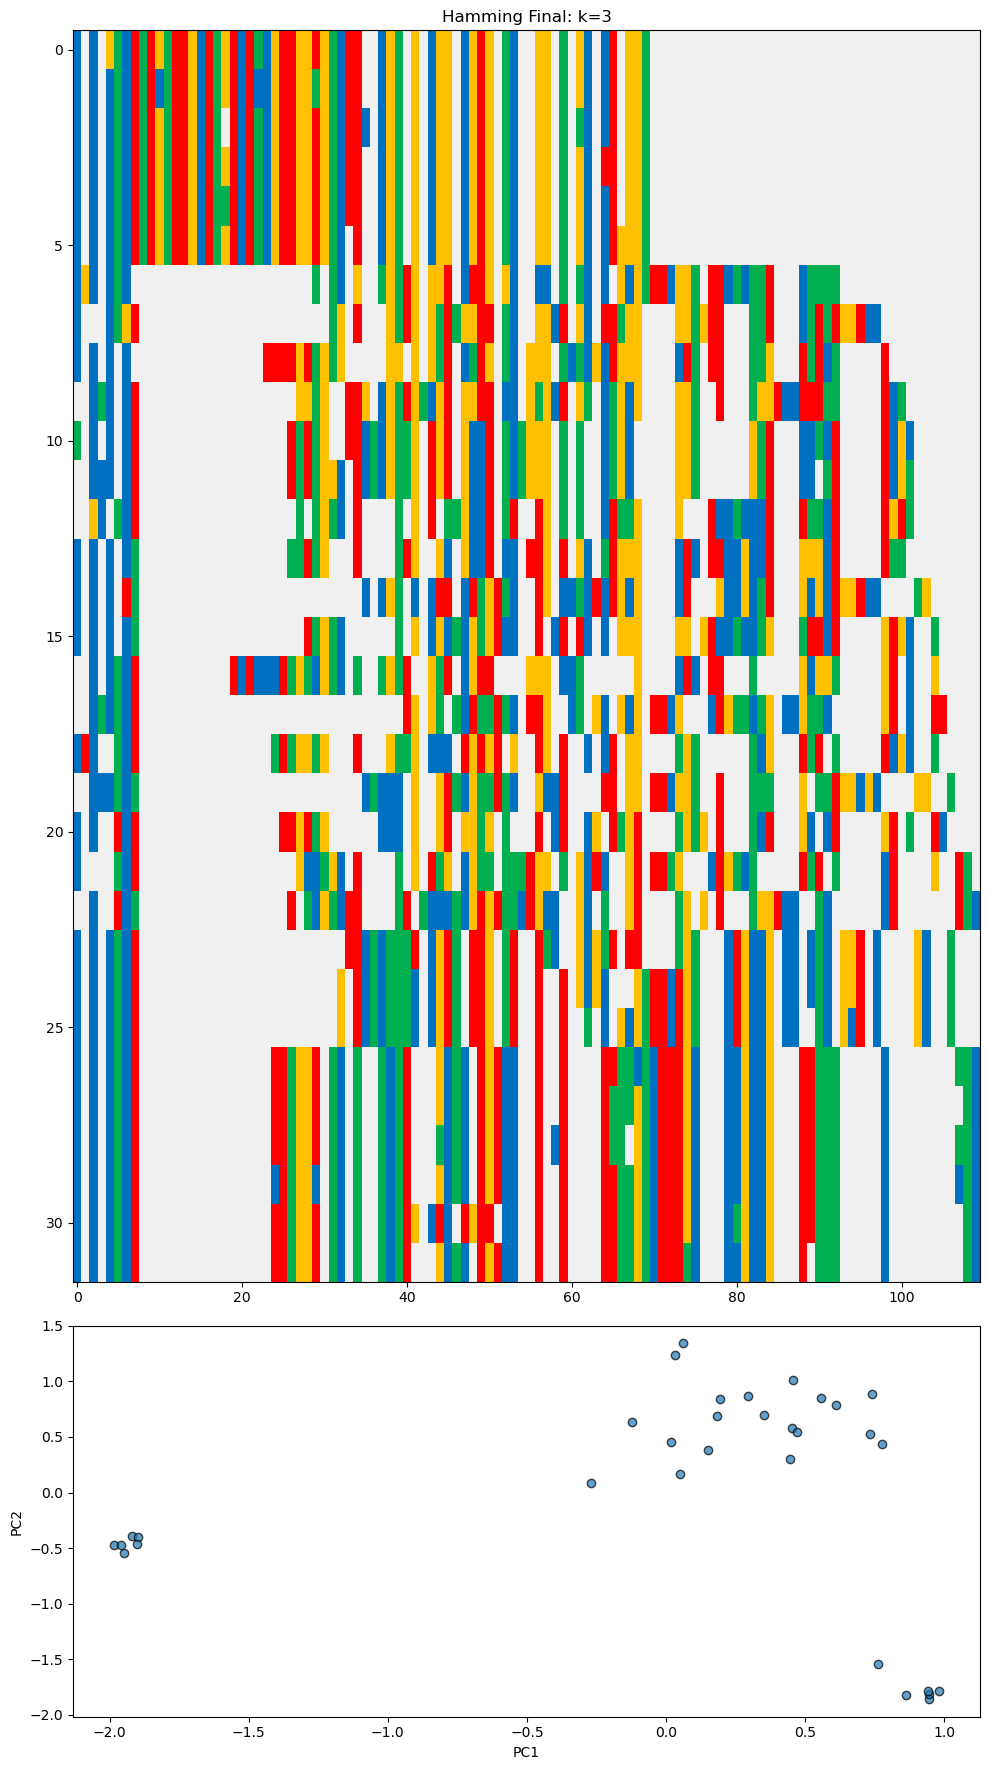

[DEBUG] Existing clusters: [0 1 2]. Checking which one split...
[DEBUG] >> Parent Cluster 2 (N=20) split into: [2 3]
[DEBUG]    Split Sizes: {2: 15, 3: 5}
    Checking split of Cluster 2 -> New sizes 15 vs 5
[DEBUG]    Generating plot for proposal...


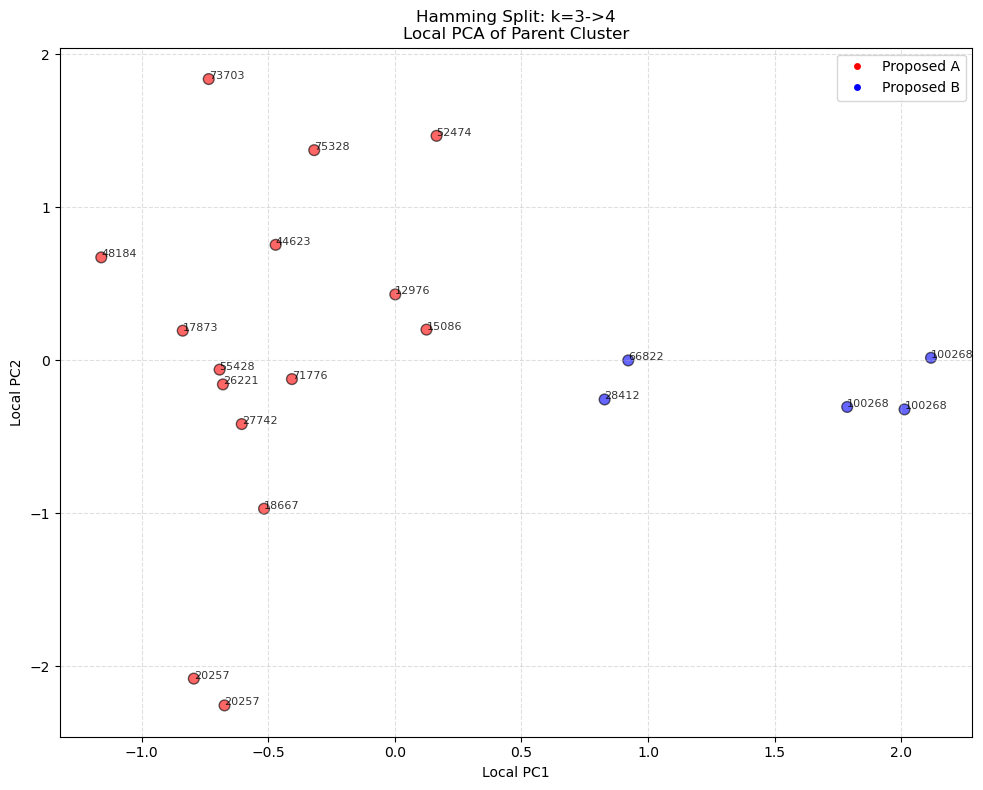

[DEBUG]    Calling validate_split_percentile()...
signal distance is 39.98280334472656
      [Val] Auto-Accept: Signal dist 40.0 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=4 justified.

[DEBUG] --- Iteration k=4 -> k=5 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


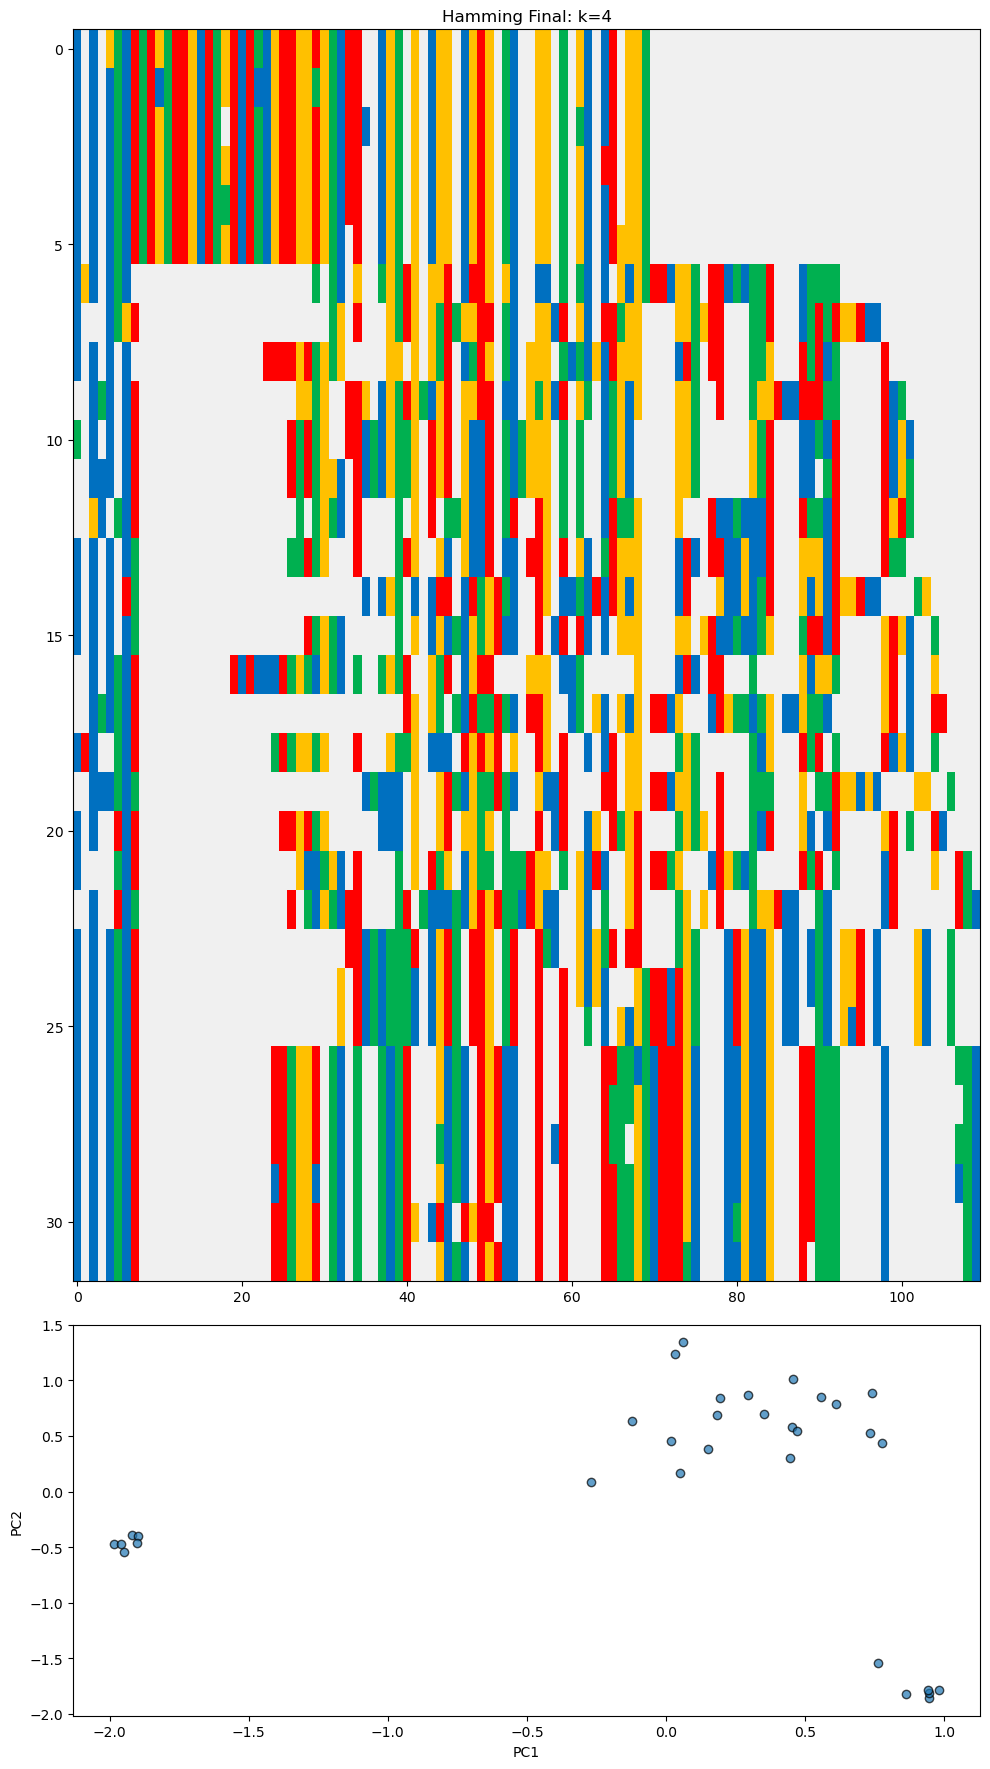

[DEBUG] Existing clusters: [0 1 2 3]. Checking which one split...
[DEBUG] >> Parent Cluster 2 (N=15) split into: [2 4]
[DEBUG]    Split Sizes: {2: 12, 4: 3}
    Checking split of Cluster 2 -> New sizes 12 vs 3
[DEBUG]    Generating plot for proposal...


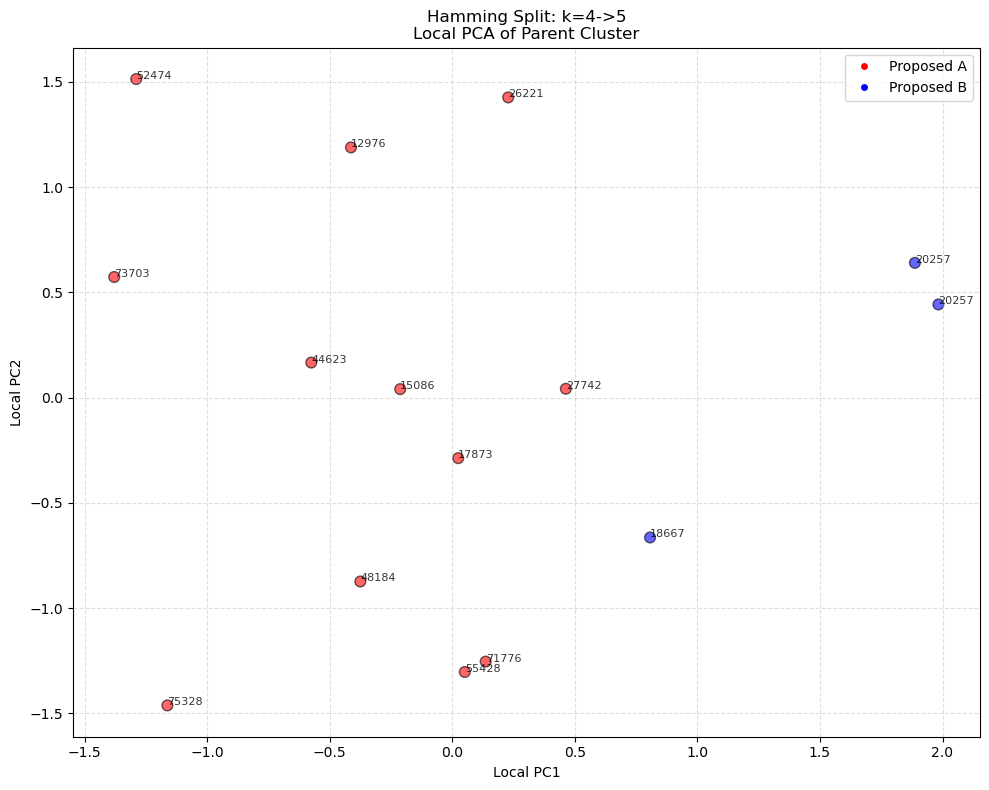

[DEBUG]    Calling validate_split_percentile()...
signal distance is 37.16865158081055
      [Val] Auto-Accept: Signal dist 37.2 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=5 justified.

[DEBUG] --- Iteration k=5 -> k=6 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


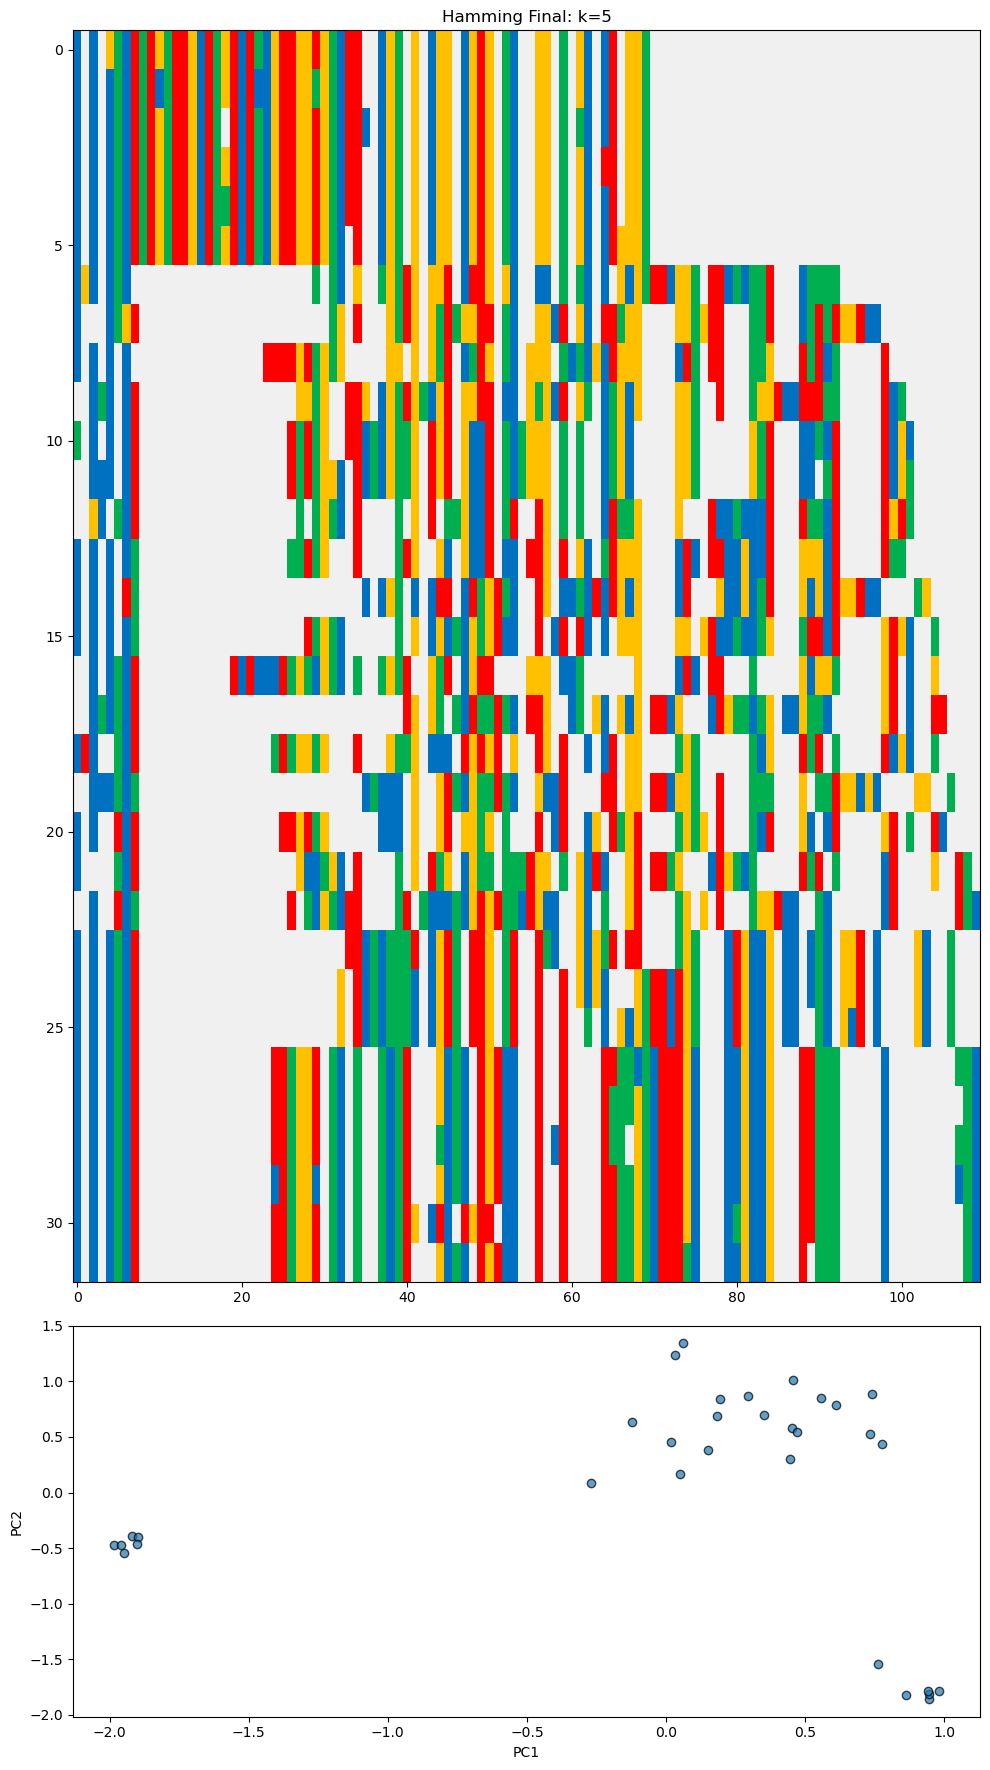

[DEBUG] Existing clusters: [0 1 2 3 4]. Checking which one split...
[DEBUG] >> Parent Cluster 2 (N=12) split into: [2 3]
[DEBUG]    Split Sizes: {2: 9, 3: 3}
    Checking split of Cluster 2 -> New sizes 9 vs 3
[DEBUG]    Generating plot for proposal...


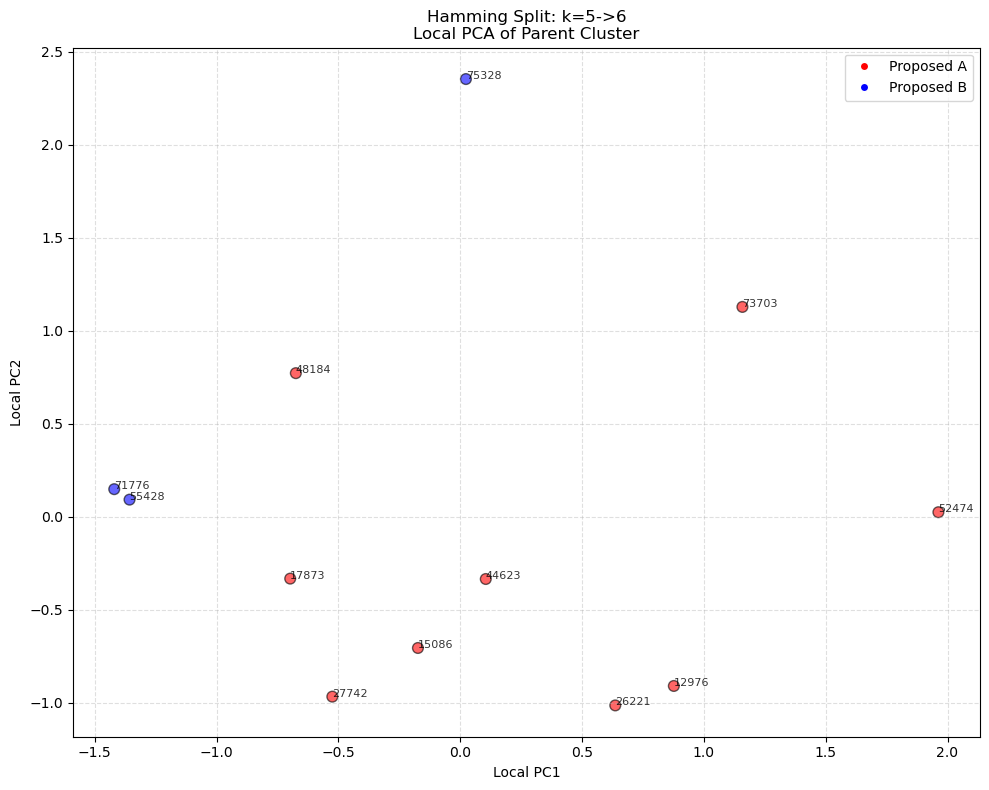

[DEBUG]    Calling validate_split_percentile()...
signal distance is 38.87651443481445
      [Val] Auto-Accept: Signal dist 38.9 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=6 justified.

[DEBUG] --- Iteration k=6 -> k=7 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


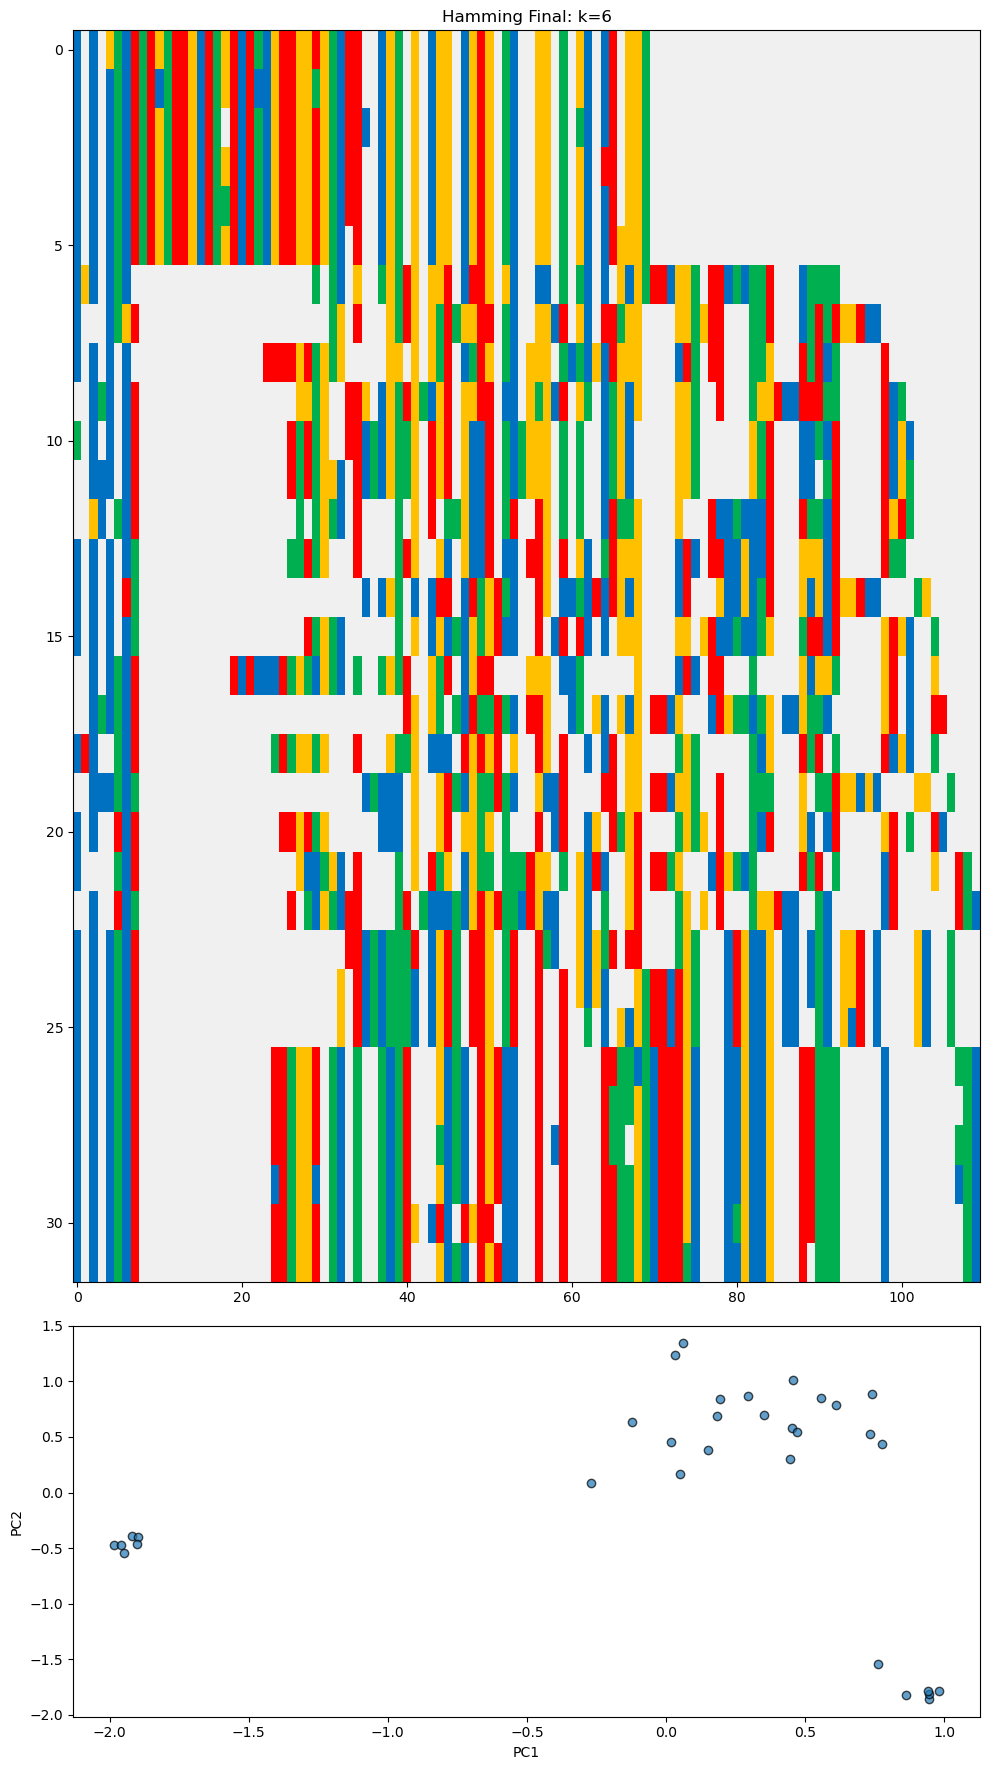

[DEBUG] Existing clusters: [0 1 2 3 4 5]. Checking which one split...
[DEBUG] >> Parent Cluster 2 (N=10) split into: [2 3 4]
[DEBUG]    Split Sizes: {2: 5, 4: 4, 3: 1}
    Checking split of Cluster 2 -> New sizes 5 vs 4
[DEBUG]    Generating plot for proposal...


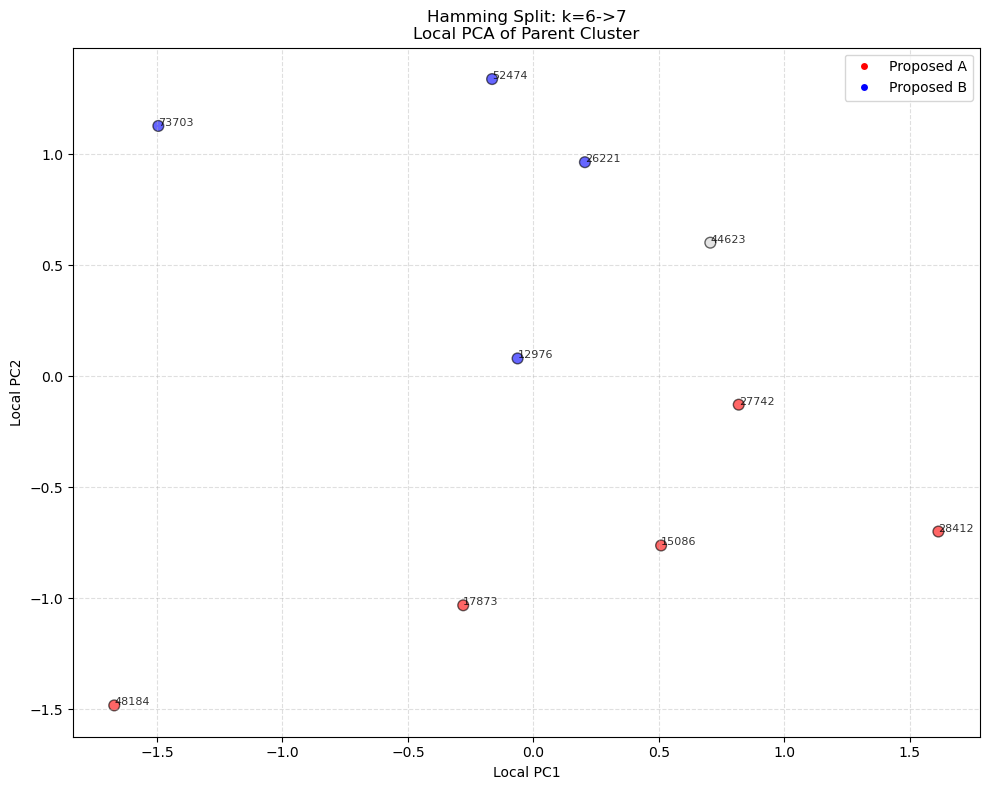

[DEBUG]    Calling validate_split_percentile()...
signal distance is 39.491817474365234
      [Val] Auto-Accept: Signal dist 39.5 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=7 justified.

[DEBUG] --- Iteration k=7 -> k=8 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


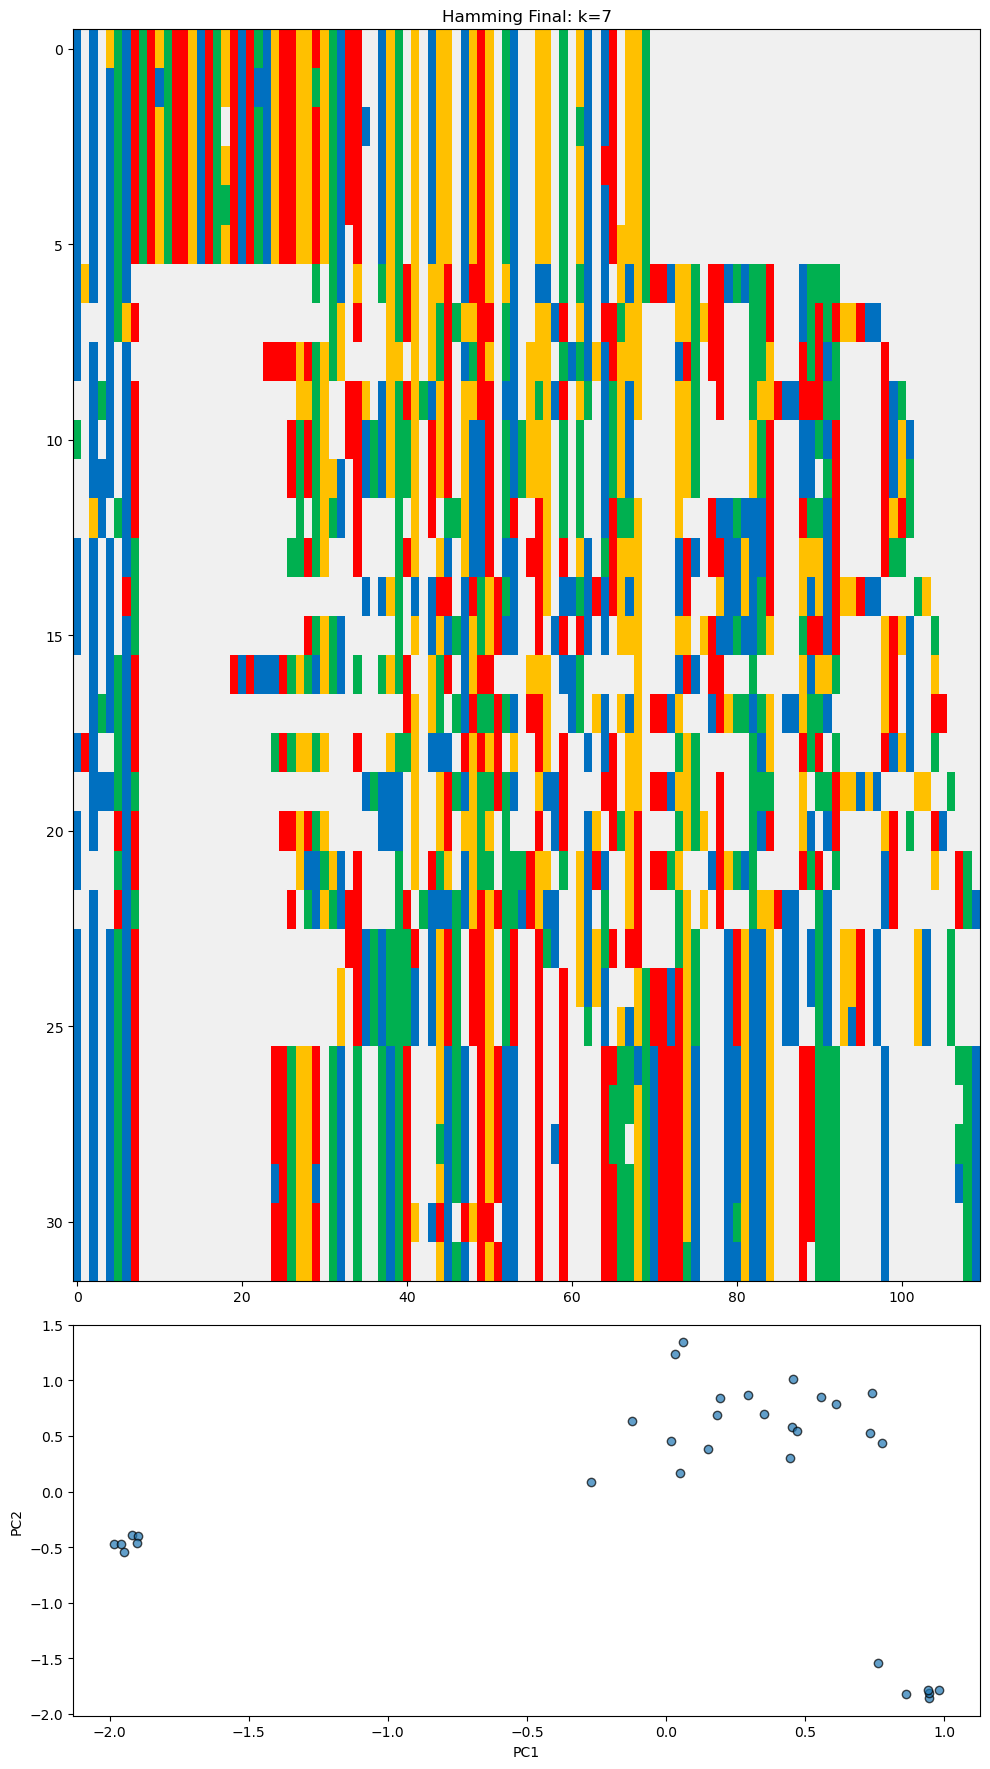

[DEBUG] Existing clusters: [0 1 2 3 4 5 6]. Checking which one split...
[DEBUG] >> Parent Cluster 2 (N=6) split into: [5 7]
[DEBUG]    Split Sizes: {5: 5, 7: 1}
    Checking split of Cluster 2 -> New sizes 5 vs 1
[DEBUG]    Generating plot for proposal...


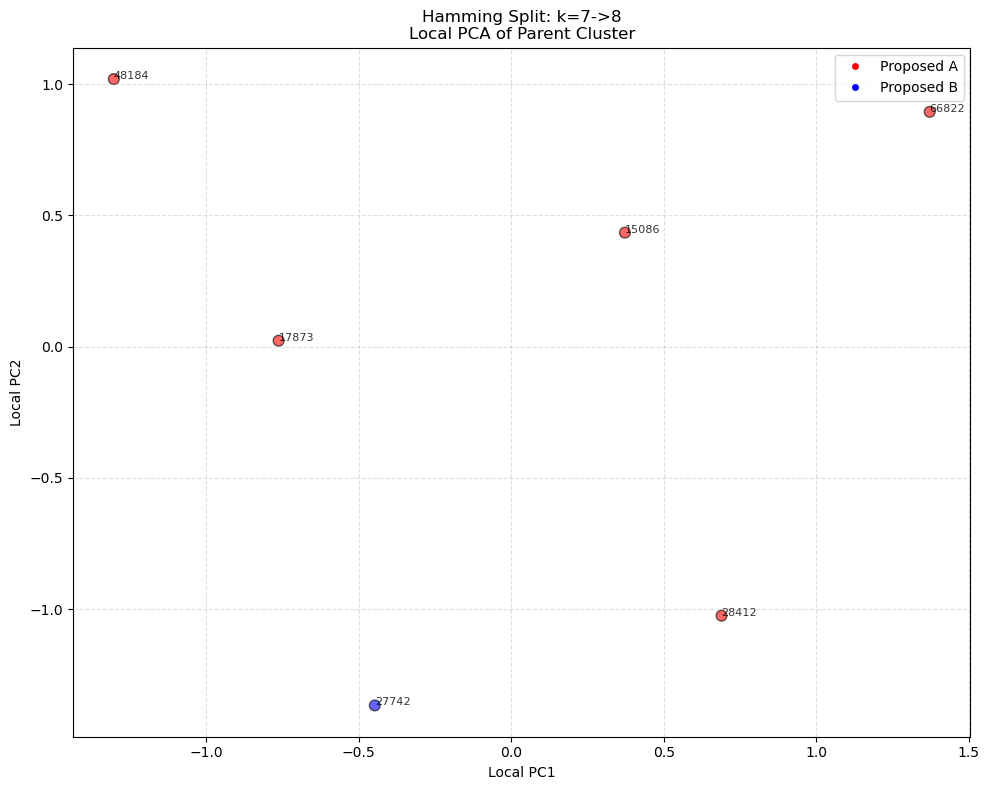

[DEBUG]    Calling validate_split_percentile()...
signal distance is 40.10041046142578
      [Val] Auto-Accept: Signal dist 40.1 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=8 justified.

[DEBUG] --- Iteration k=8 -> k=9 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


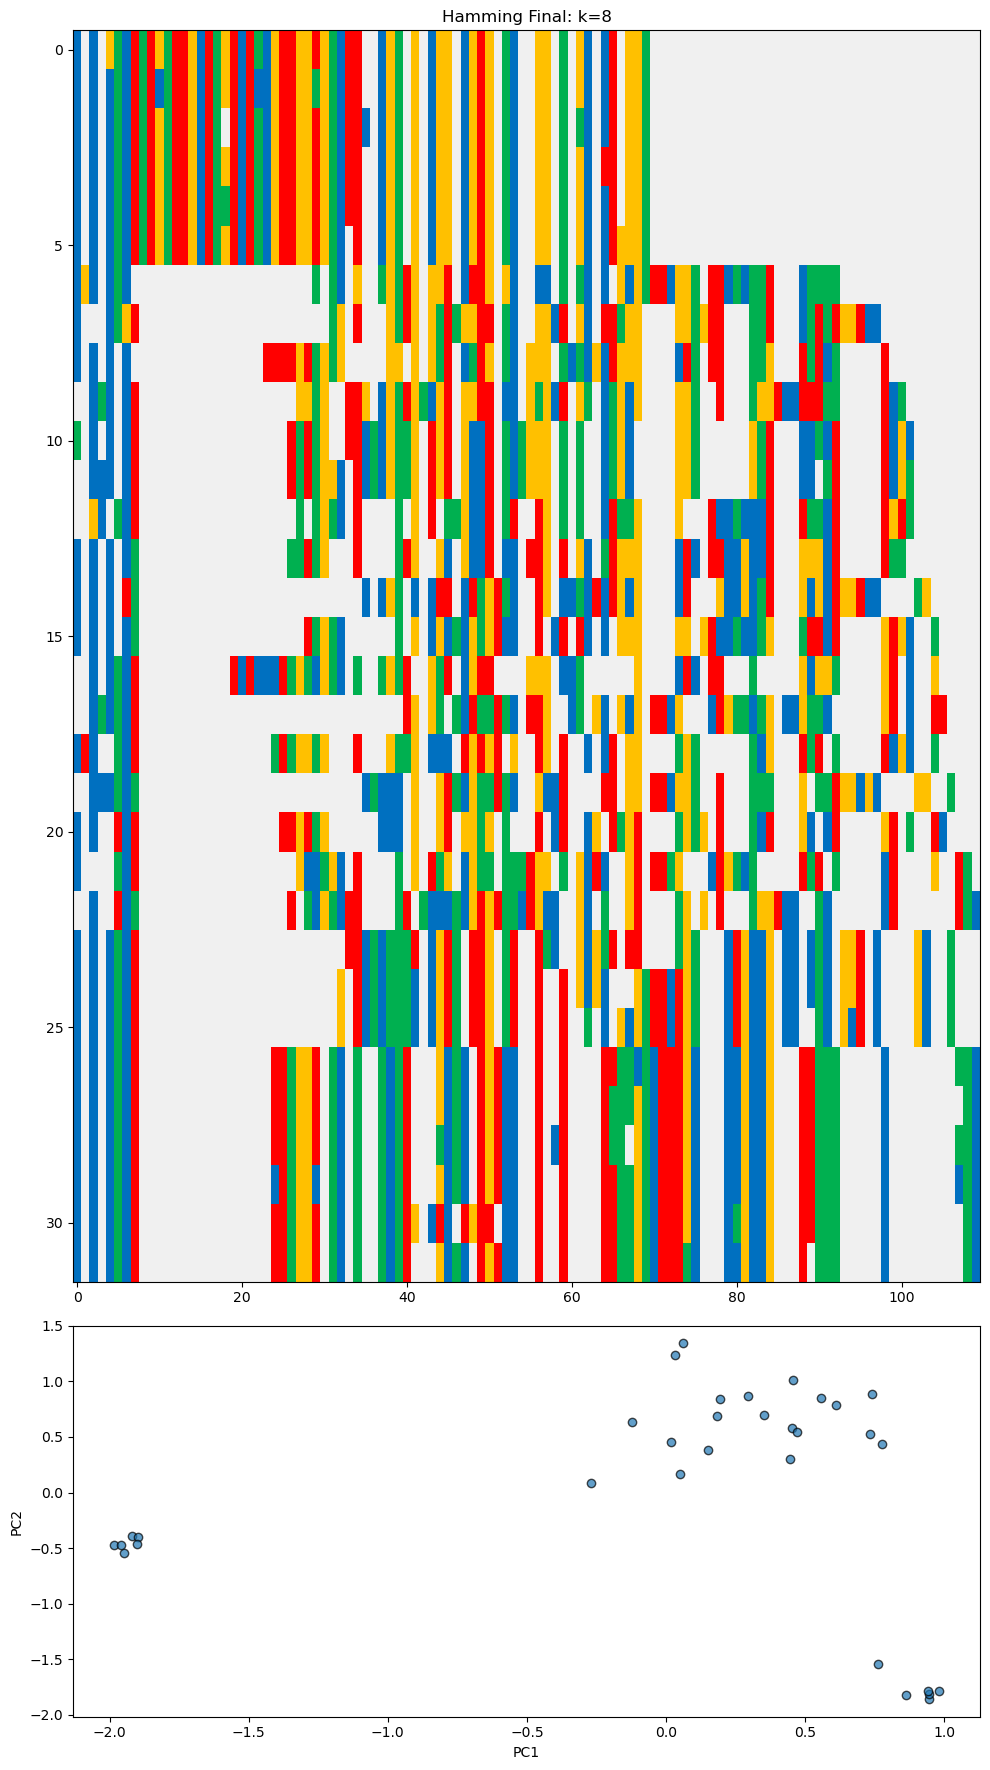

[DEBUG] Existing clusters: [0 1 2 3 4 5 6 7]. Checking which one split...
[DEBUG] >> Parent Cluster 5 (N=6) split into: [1 6 7 8]
[DEBUG]    Split Sizes: {8: 2, 7: 2, 1: 1, 6: 1}
    Checking split of Cluster 5 -> New sizes 2 vs 2
[DEBUG]    Generating plot for proposal...


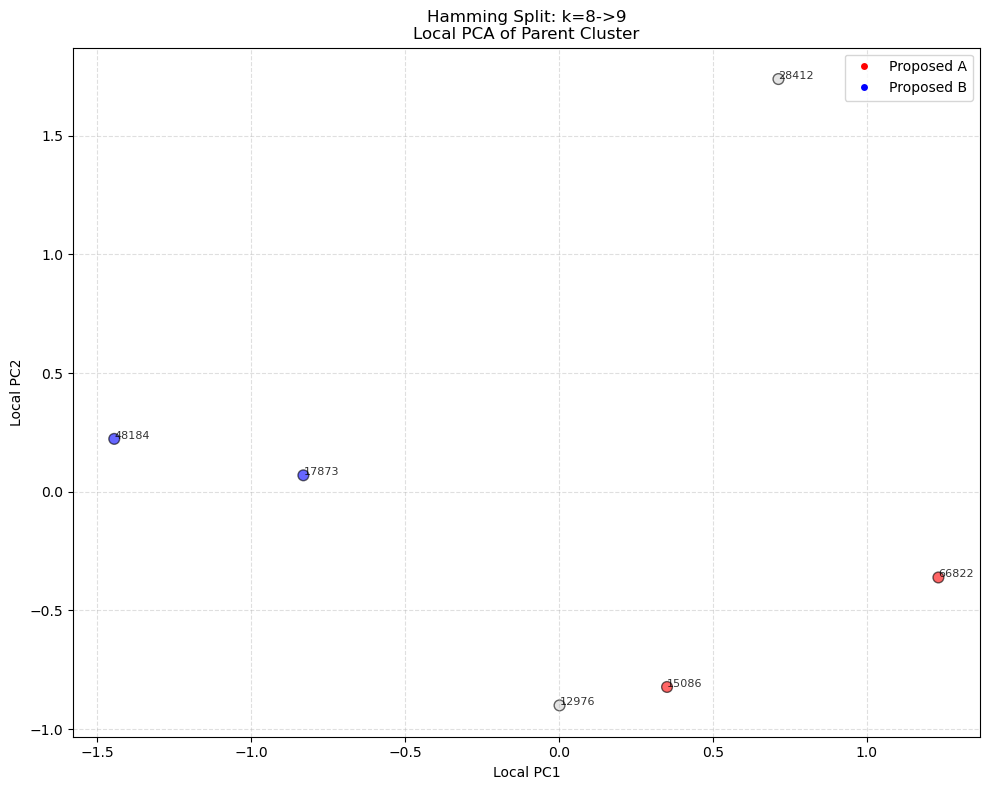

[DEBUG]    Calling validate_split_percentile()...
signal distance is 40.4040412902832
      [Val] Auto-Accept: Signal dist 40.4 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=9 justified.

[DEBUG] --- Iteration k=9 -> k=10 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


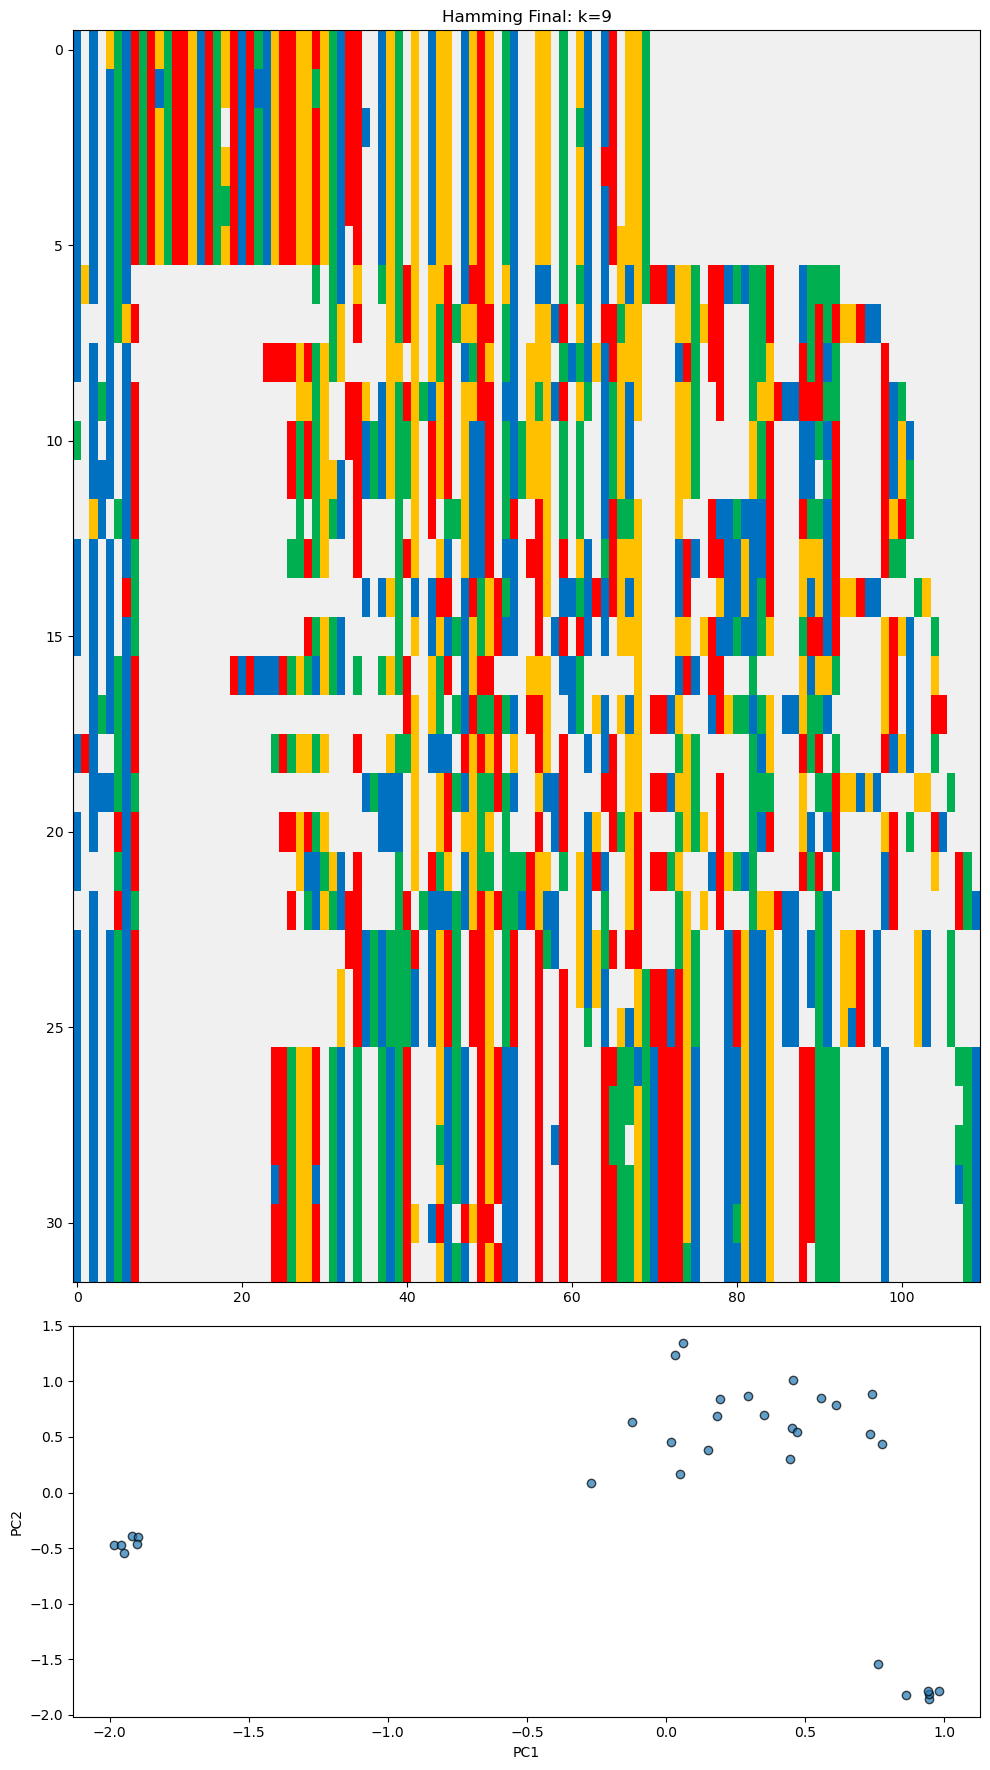

[DEBUG] Existing clusters: [0 1 2 3 4 5 6 7 8]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=3) split into: [3 7]
[DEBUG]    Split Sizes: {3: 2, 7: 1}
    Checking split of Cluster 1 -> New sizes 2 vs 1
[DEBUG]    Generating plot for proposal...


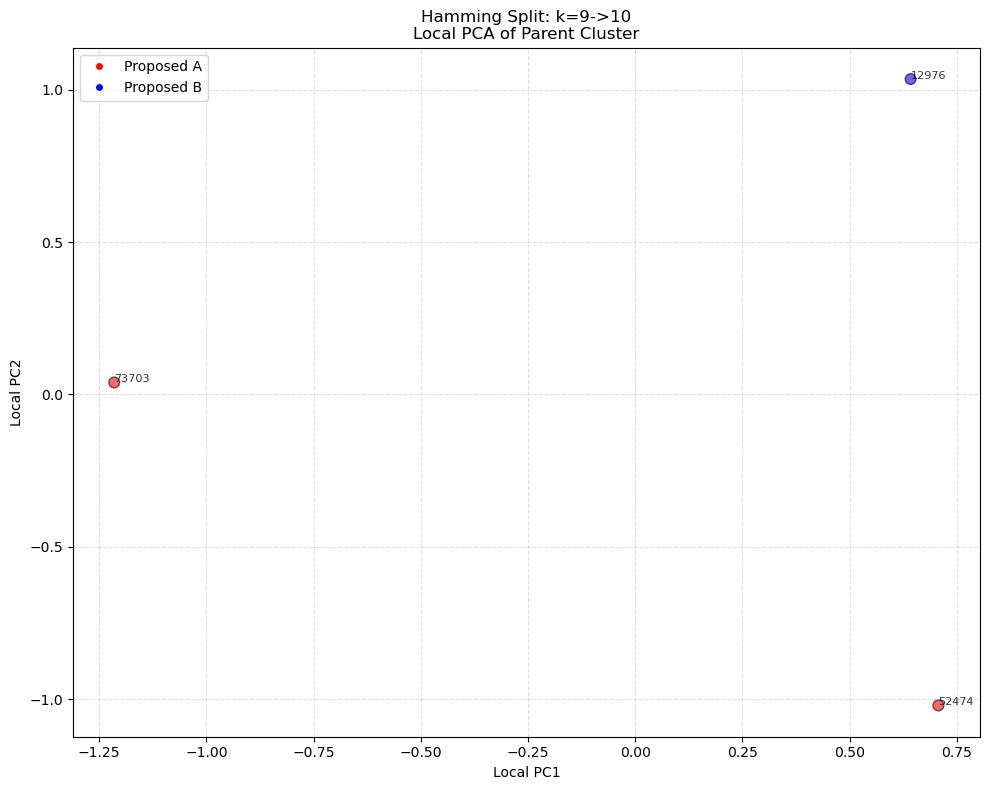

[DEBUG]    Calling validate_split_percentile()...
signal distance is 39.0
      [Val] Auto-Accept: Signal dist 39.0 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=10 justified.

[DEBUG] --- Iteration k=10 -> k=11 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


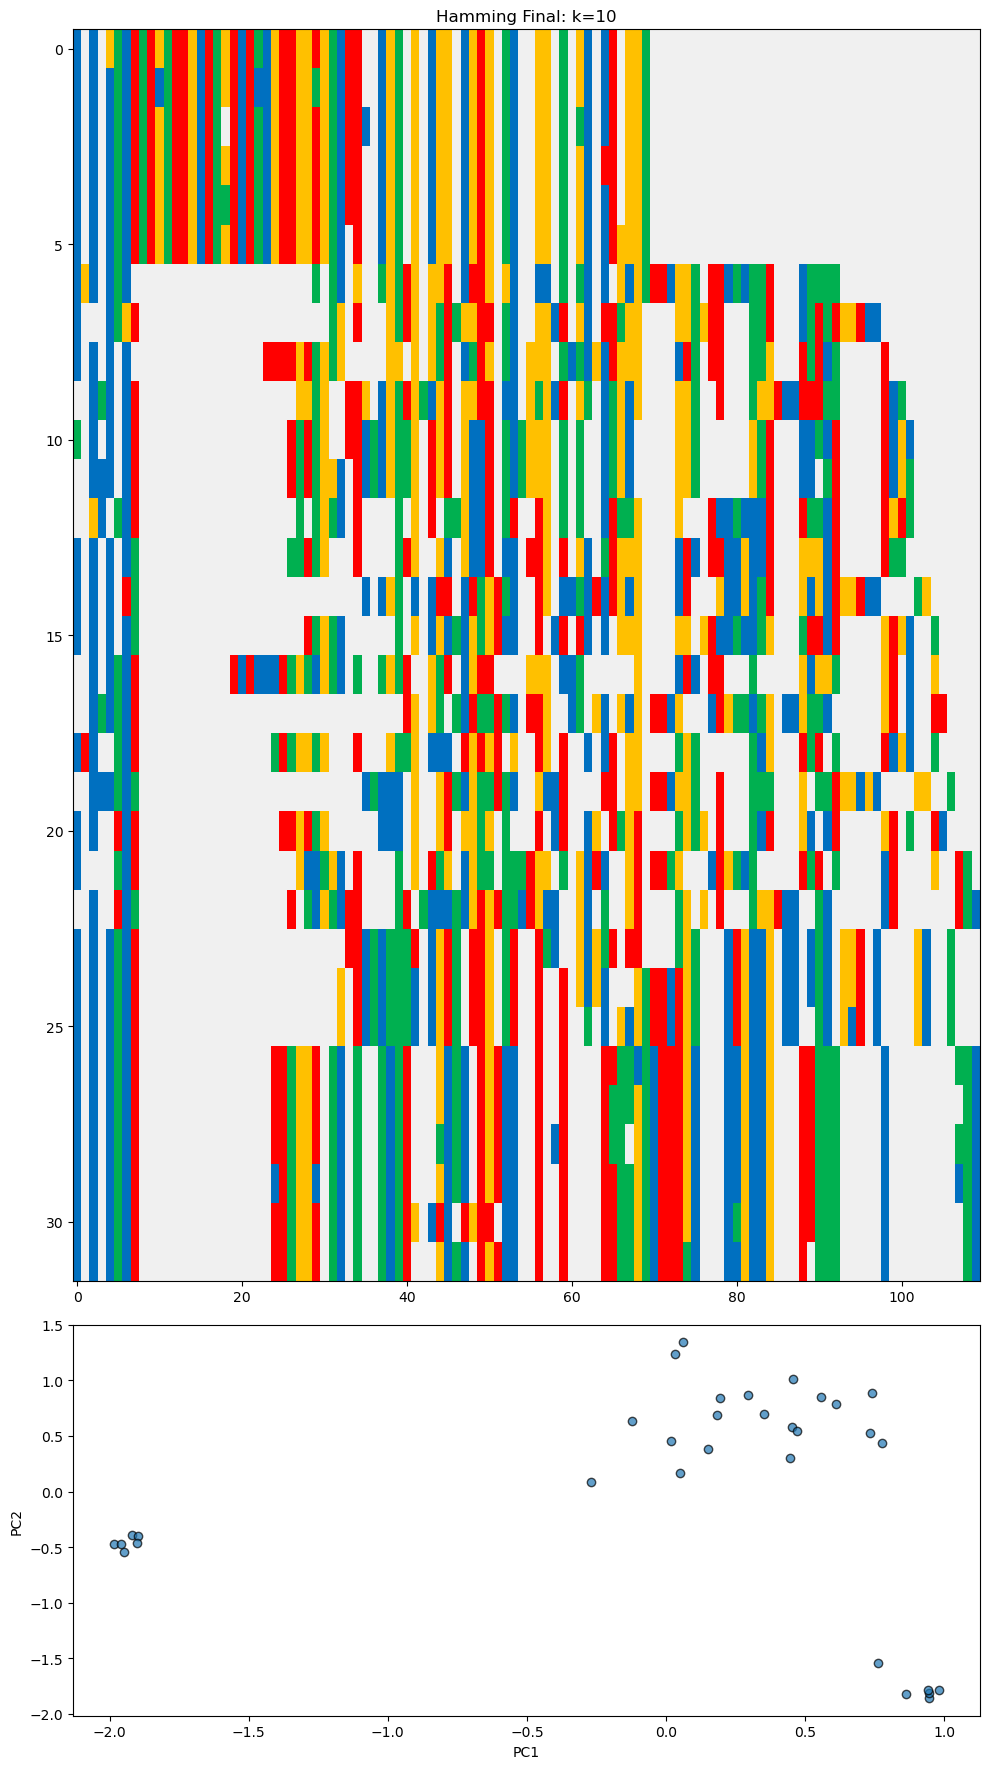

[DEBUG] Existing clusters: [0 1 2 3 4 5 6 7 8 9]. Checking which one split...
[DEBUG] >> Parent Cluster 3 (N=3) split into: [0 6 8]
[DEBUG]    Split Sizes: {8: 1, 0: 1, 6: 1}
    Checking split of Cluster 3 -> New sizes 1 vs 1
[DEBUG]    Generating plot for proposal...


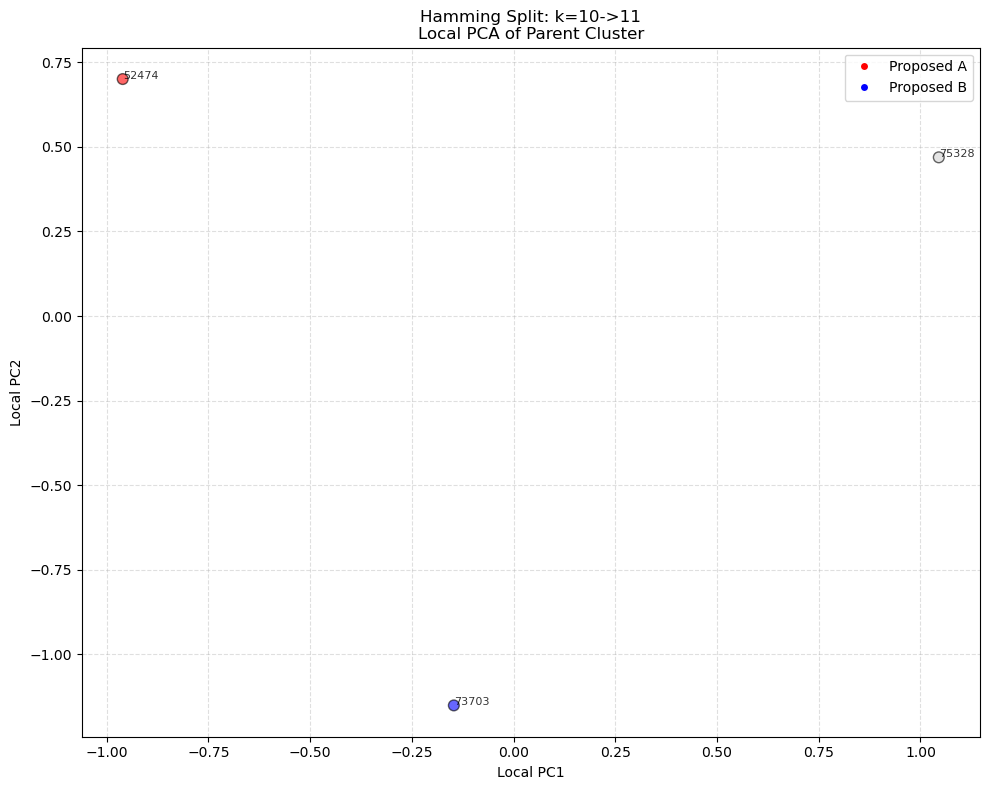

[DEBUG]    Calling validate_split_percentile()...
signal distance is 40.0
      [Val] Auto-Accept: Signal dist 40.0 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=11 justified.

[DEBUG] --- Iteration k=11 -> k=12 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


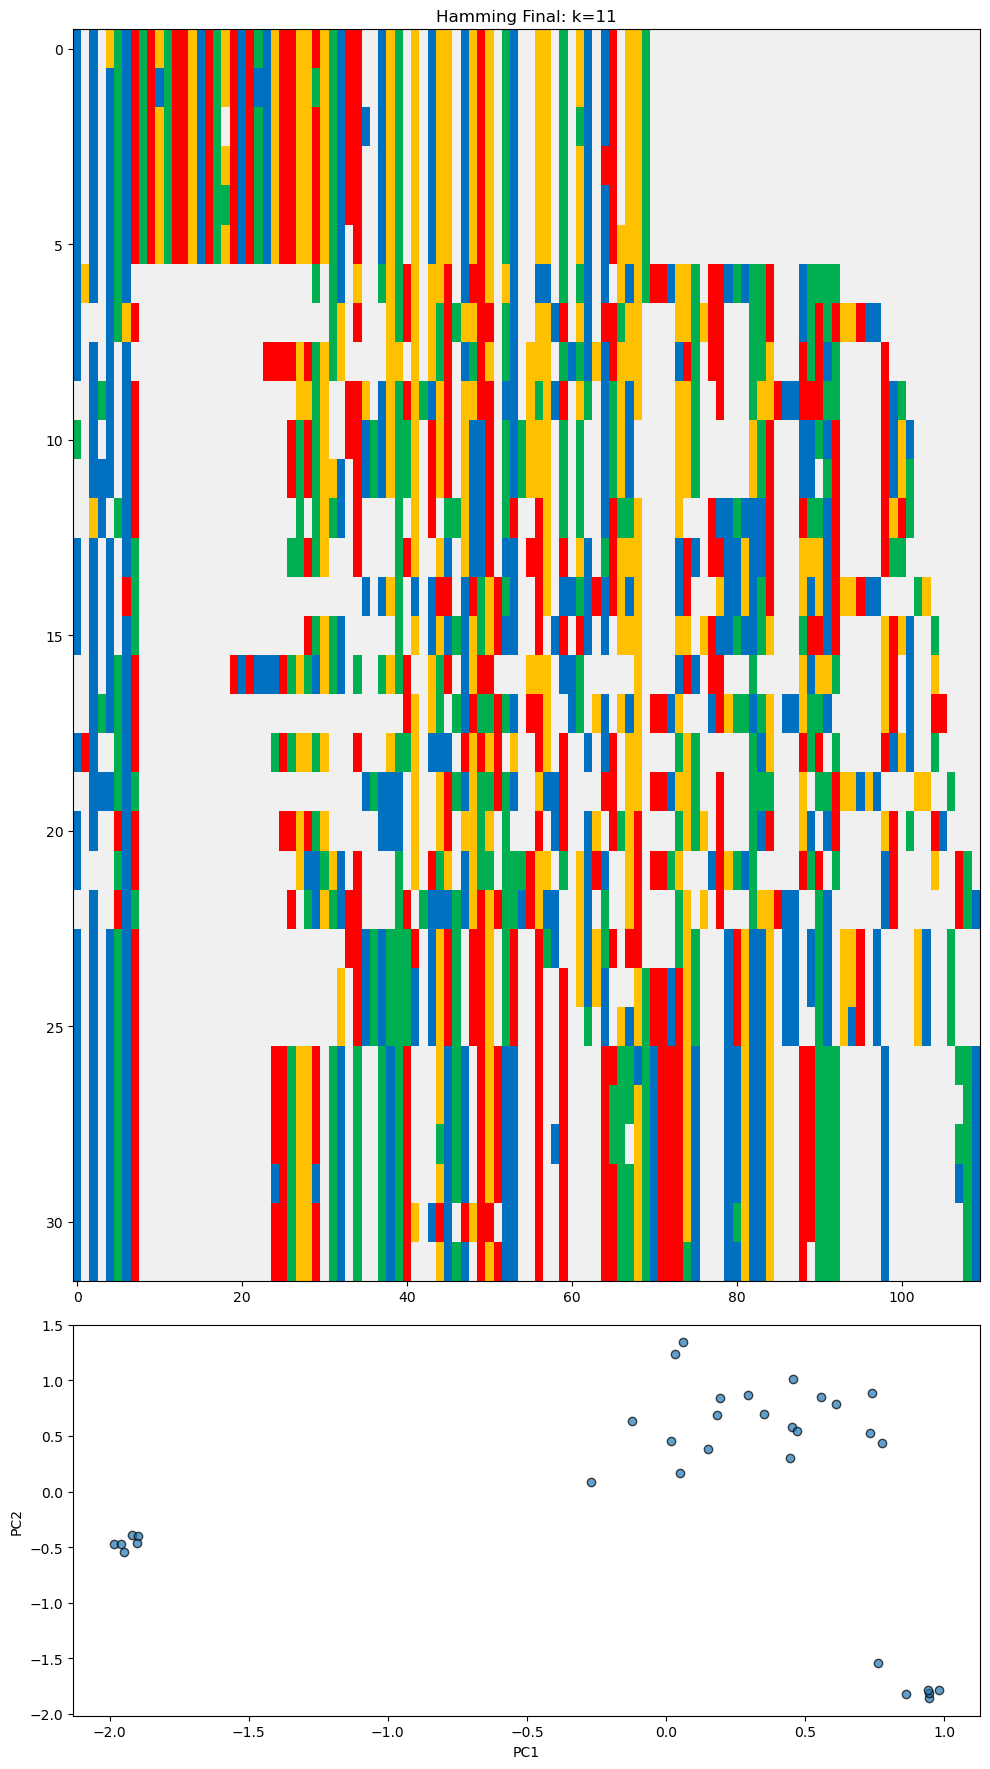

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10]. Checking which one split...
[DEBUG] >> Parent Cluster 5 (N=2) split into: [ 7 11]
[DEBUG]    Split Sizes: {11: 1, 7: 1}
    Checking split of Cluster 5 -> New sizes 1 vs 1
[DEBUG]    Generating plot for proposal...
[DEBUG]    Calling validate_split_percentile()...
signal distance is 40.0
      [Val] Auto-Accept: Signal dist 40.0 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=12 justified.

[DEBUG] --- Iteration k=12 -> k=13 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


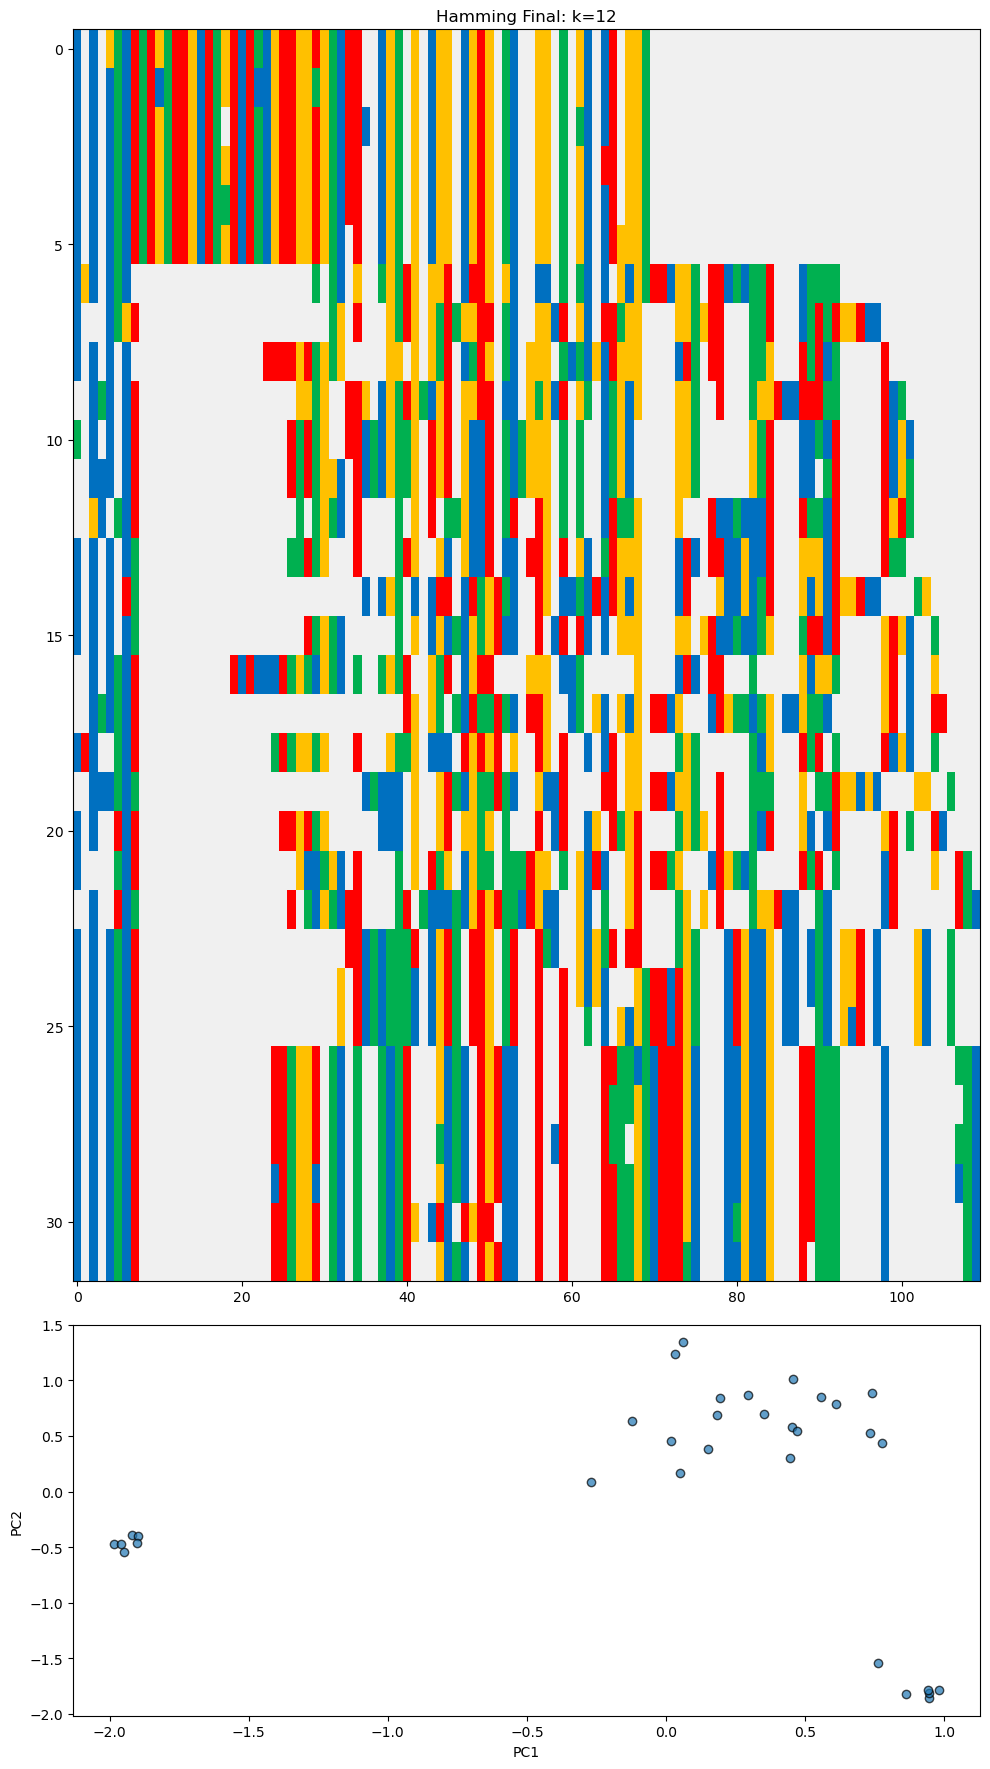

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11]. Checking which one split...
[DEBUG] >> Parent Cluster 0 (N=2) split into: [8 9]
[DEBUG]    Split Sizes: {9: 1, 8: 1}
    Checking split of Cluster 0 -> New sizes 1 vs 1
[DEBUG]    Generating plot for proposal...
[DEBUG]    Calling validate_split_percentile()...
signal distance is 44.0
      [Val] Auto-Accept: Signal dist 44.0 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=13 justified.

[DEBUG] --- Iteration k=13 -> k=14 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


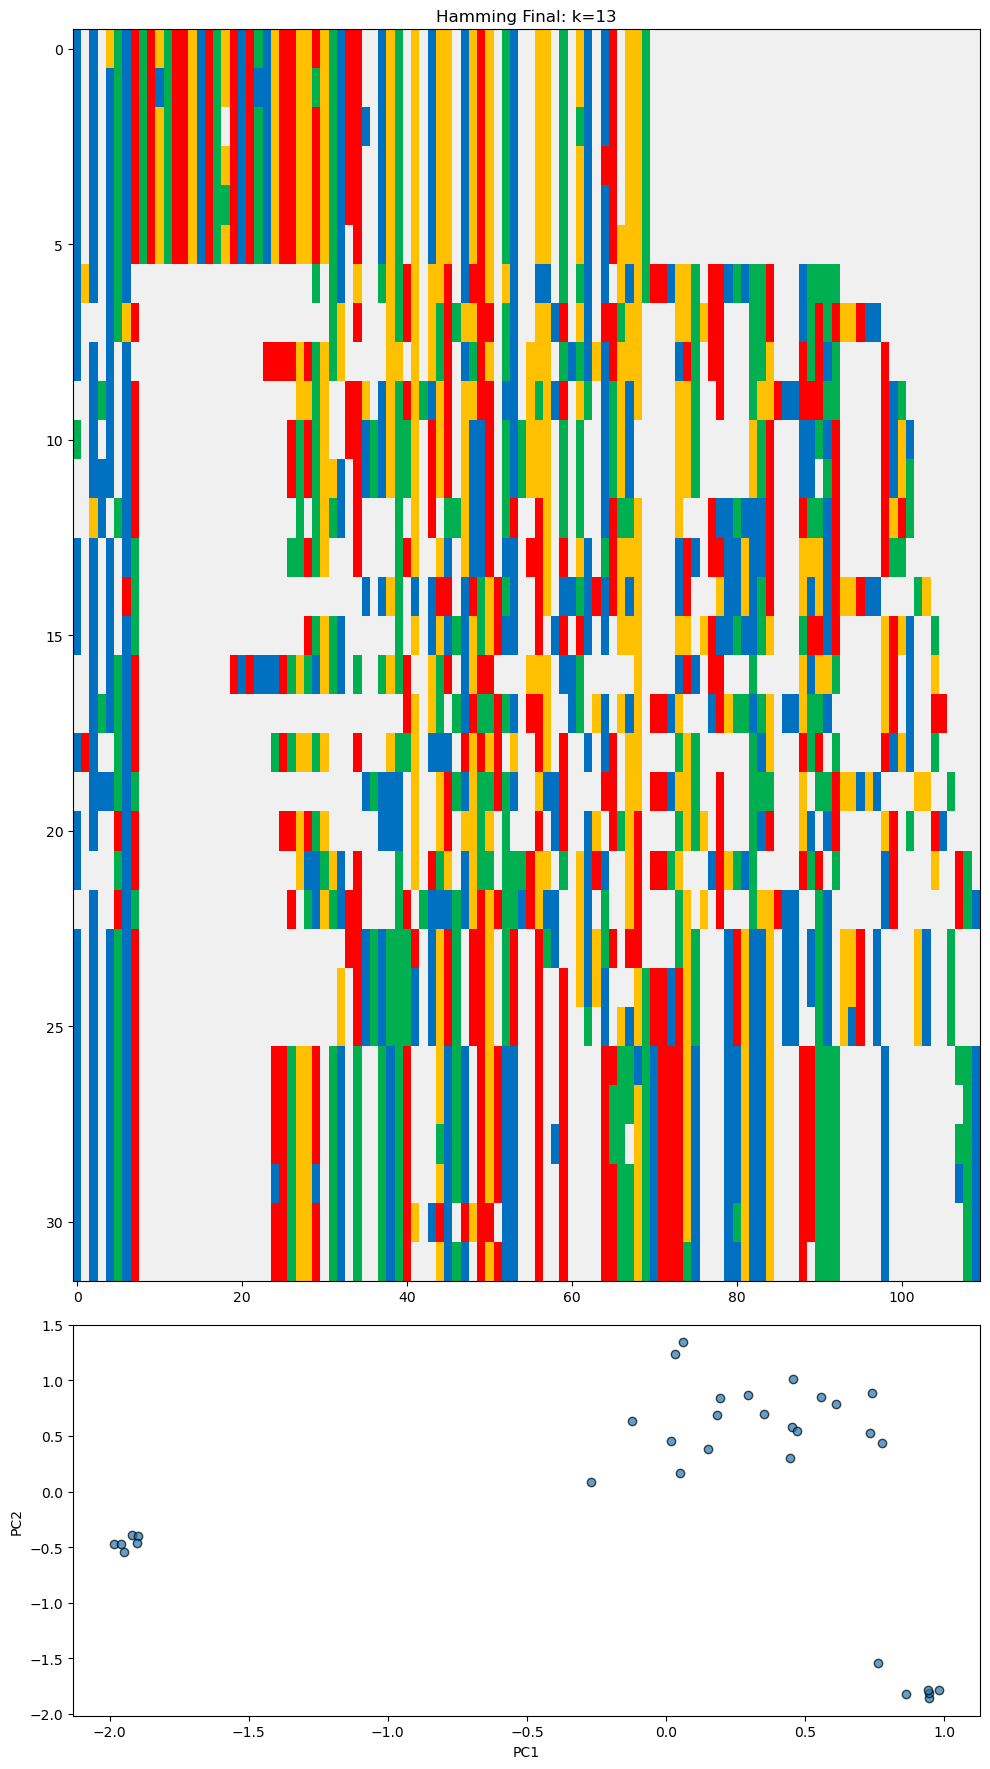

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=7) split into: [0 9]
[DEBUG]    Split Sizes: {0: 6, 9: 1}
    Checking split of Cluster 1 -> New sizes 6 vs 1
[DEBUG]    Generating plot for proposal...


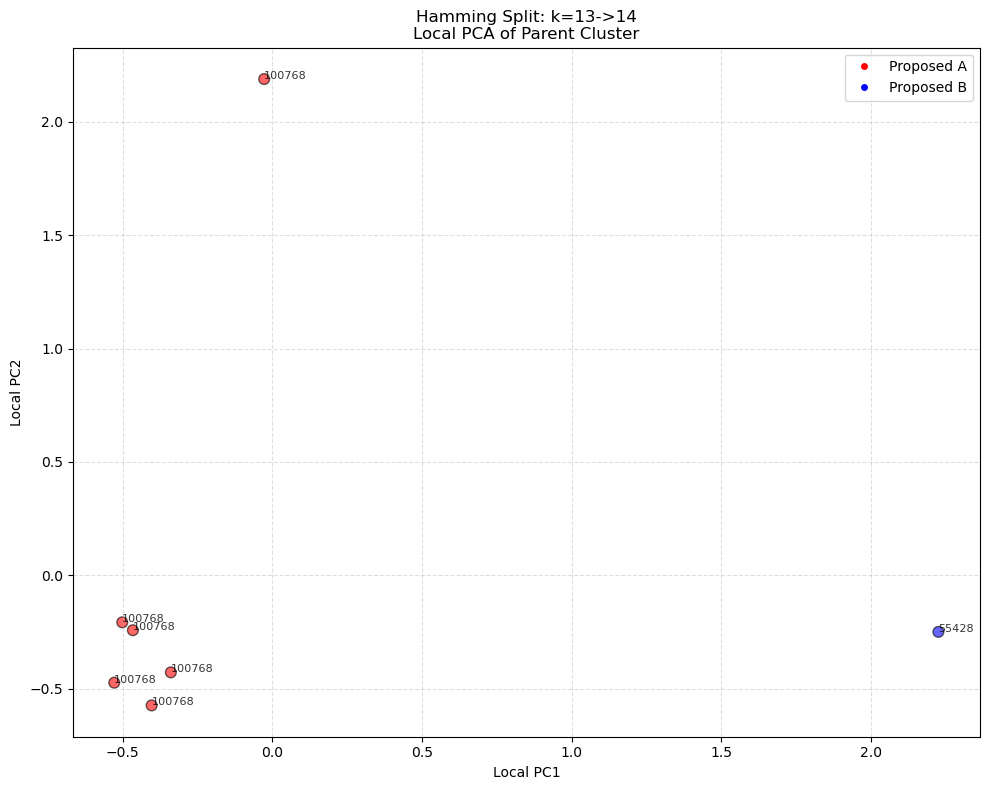

[DEBUG]    Calling validate_split_percentile()...
signal distance is 34.97703170776367
      [Val] Auto-Accept: Signal dist 35.0 < 15 & Length 51 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=14 justified.

[DEBUG] --- Iteration k=14 -> k=15 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


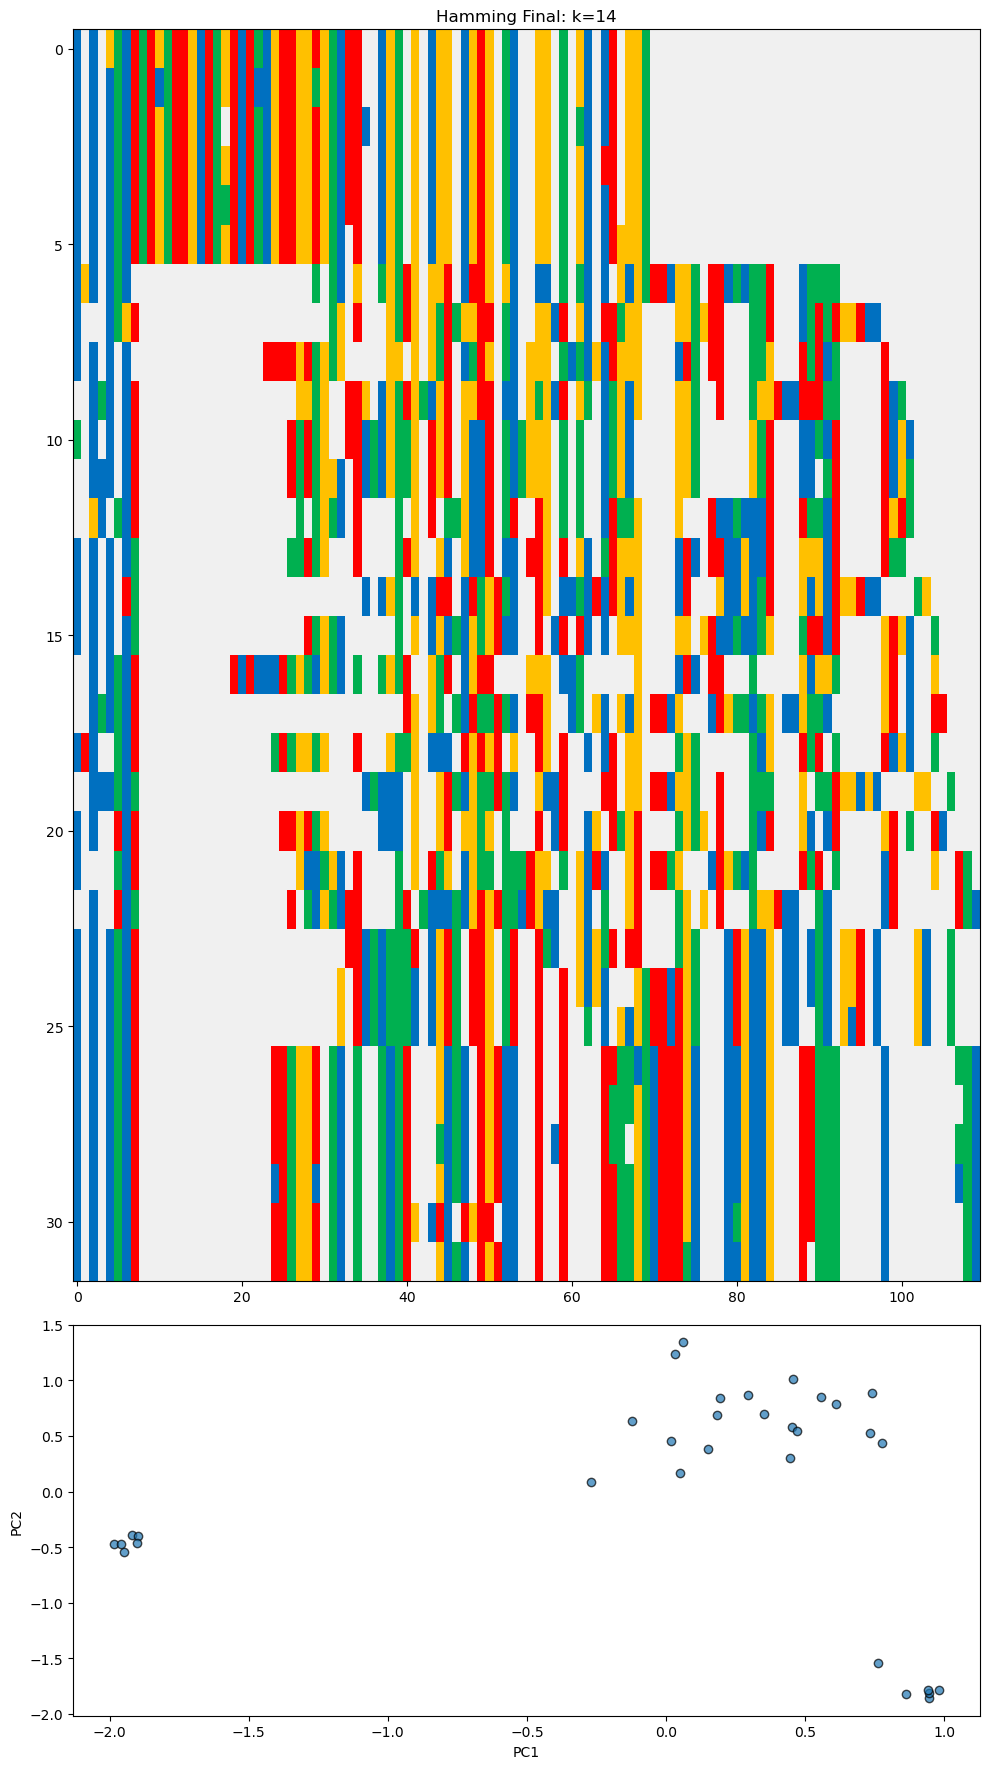

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=8) split into: [ 0  9 13]
[DEBUG]    Split Sizes: {0: 6, 13: 1, 9: 1}
    Checking split of Cluster 1 -> New sizes 6 vs 1
[DEBUG]    Generating plot for proposal...


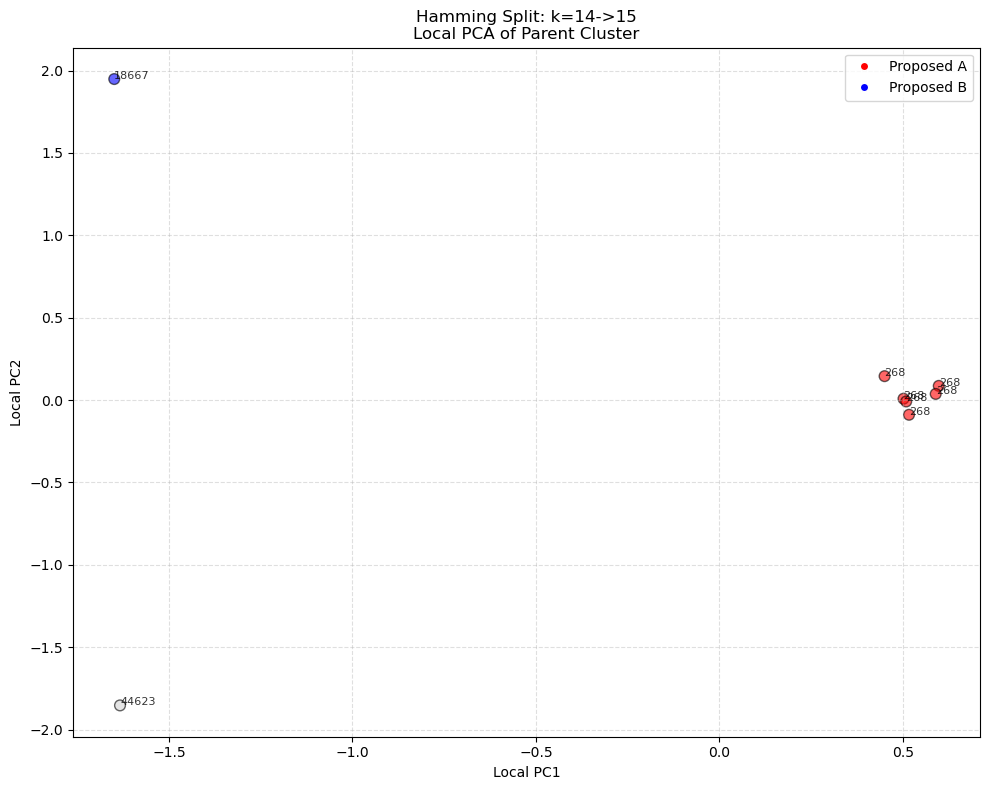

[DEBUG]    Calling validate_split_percentile()...
signal distance is 33.764835357666016
      [Val] Auto-Accept: Signal dist 33.8 < 15 & Length 50 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=15 justified.

[DEBUG] --- Iteration k=15 -> k=16 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


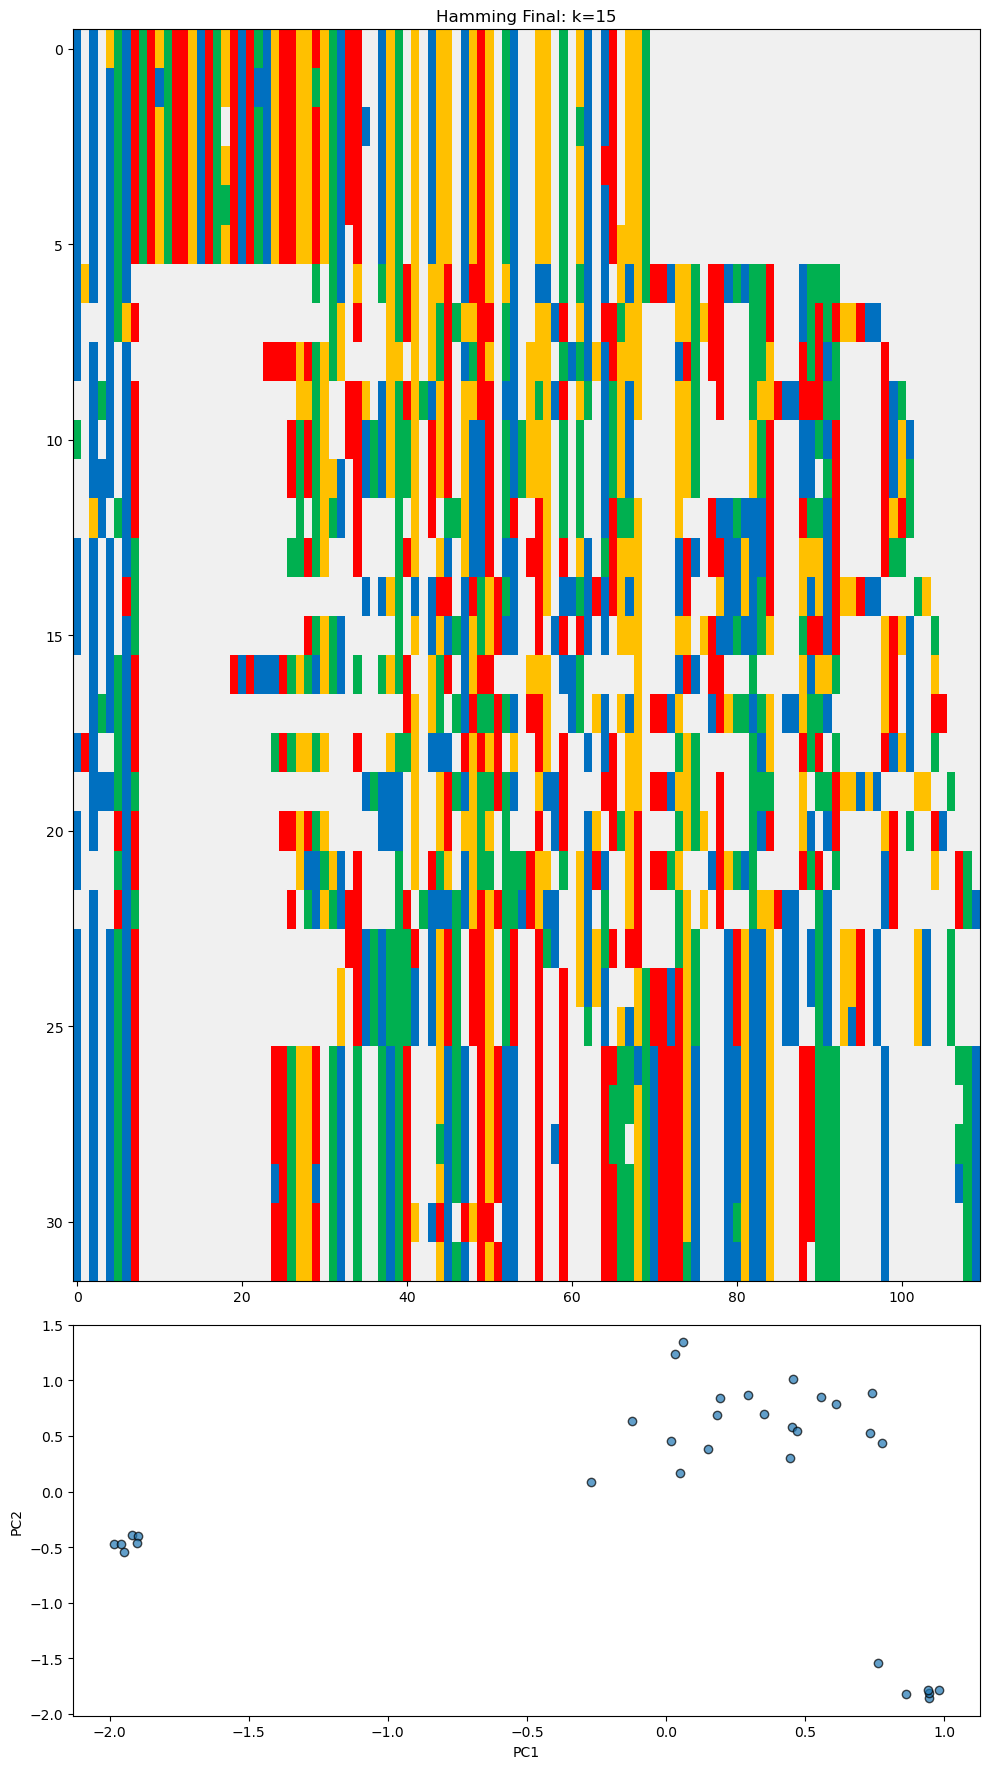

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=9) split into: [ 0 13 15]
[DEBUG]    Split Sizes: {0: 7, 13: 1, 15: 1}
    Checking split of Cluster 1 -> New sizes 7 vs 1
[DEBUG]    Generating plot for proposal...


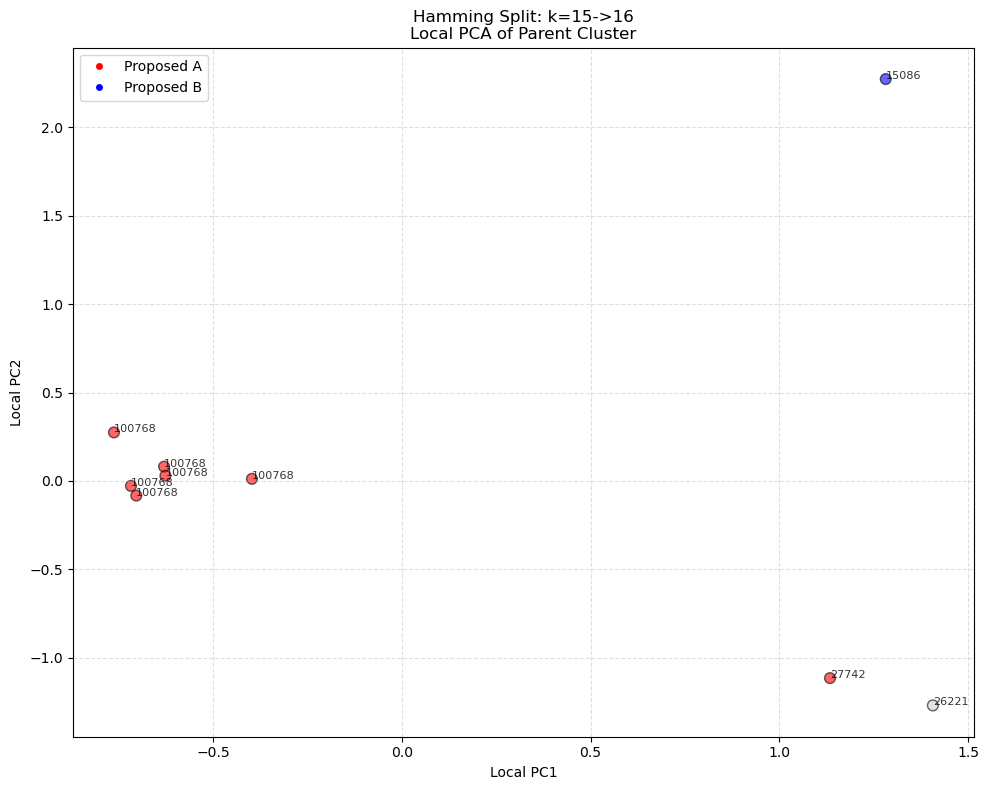

[DEBUG]    Calling validate_split_percentile()...
signal distance is 43.14658737182617
      [Val] Auto-Accept: Signal dist 43.1 < 15 & Length 51 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=16 justified.

[DEBUG] --- Iteration k=16 -> k=17 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


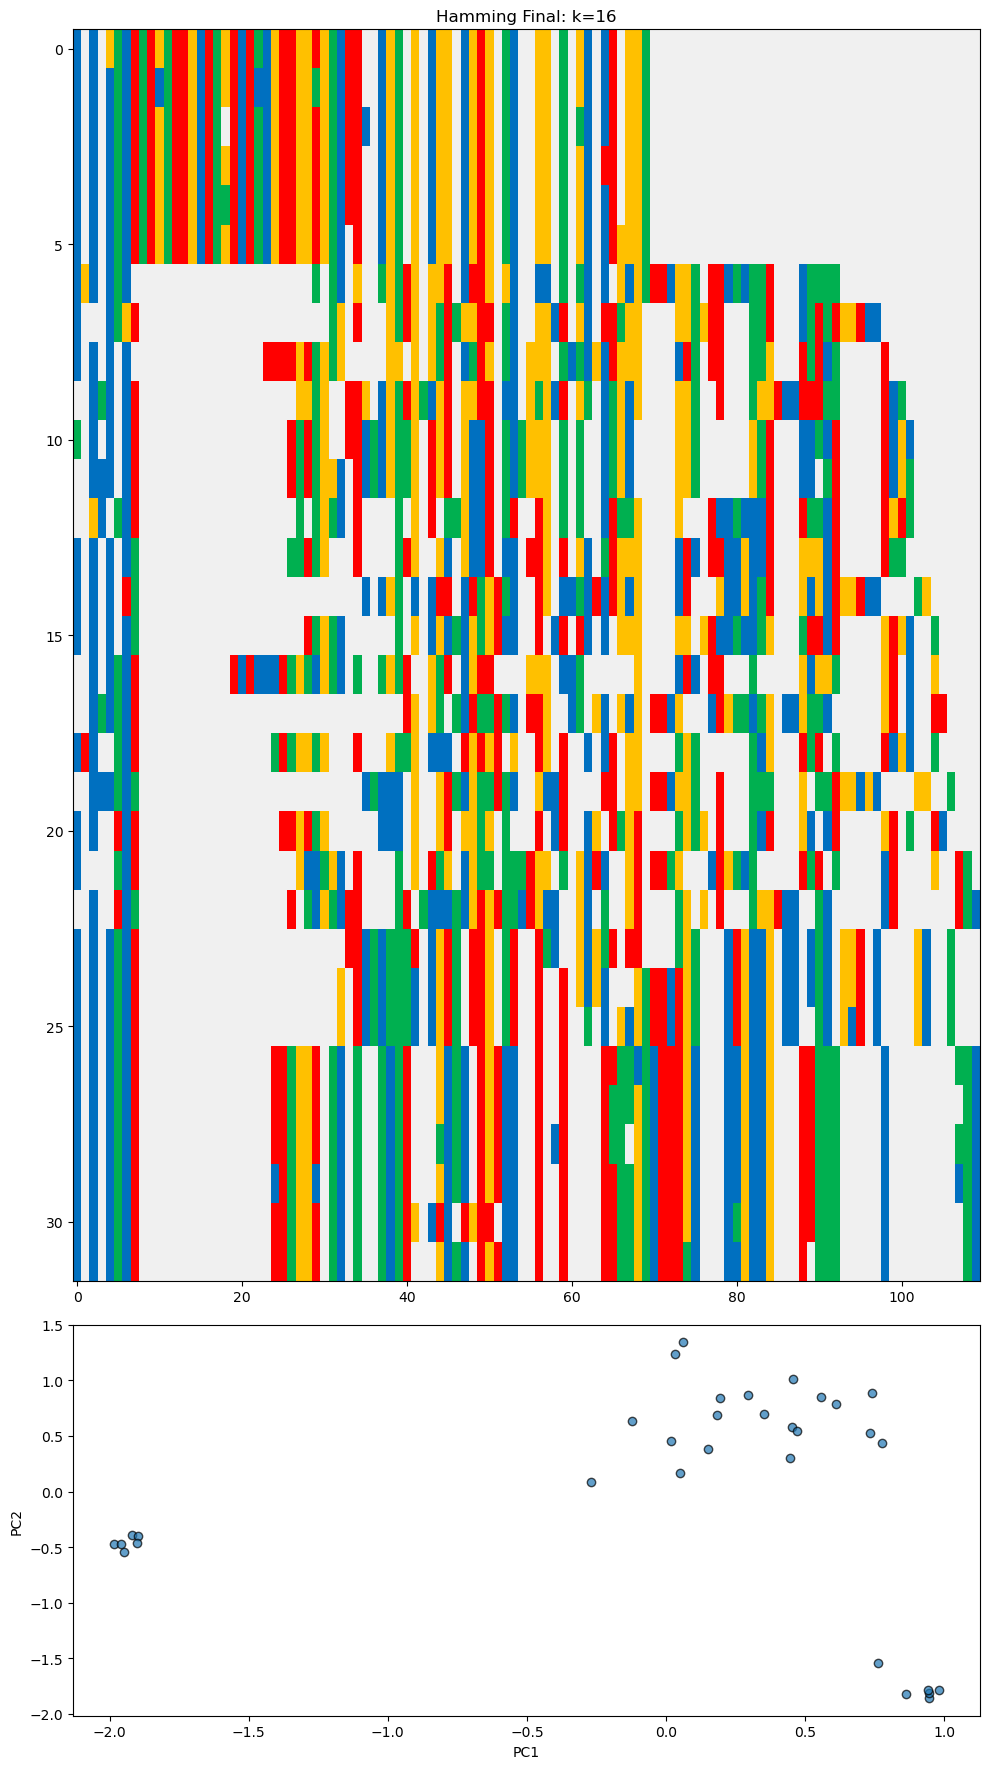

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]. Checking which one split...
[DEBUG] >> Parent Cluster 0 (N=9) split into: [ 1 12]
[DEBUG]    Split Sizes: {1: 8, 12: 1}
    Checking split of Cluster 0 -> New sizes 8 vs 1
[DEBUG]    Generating plot for proposal...


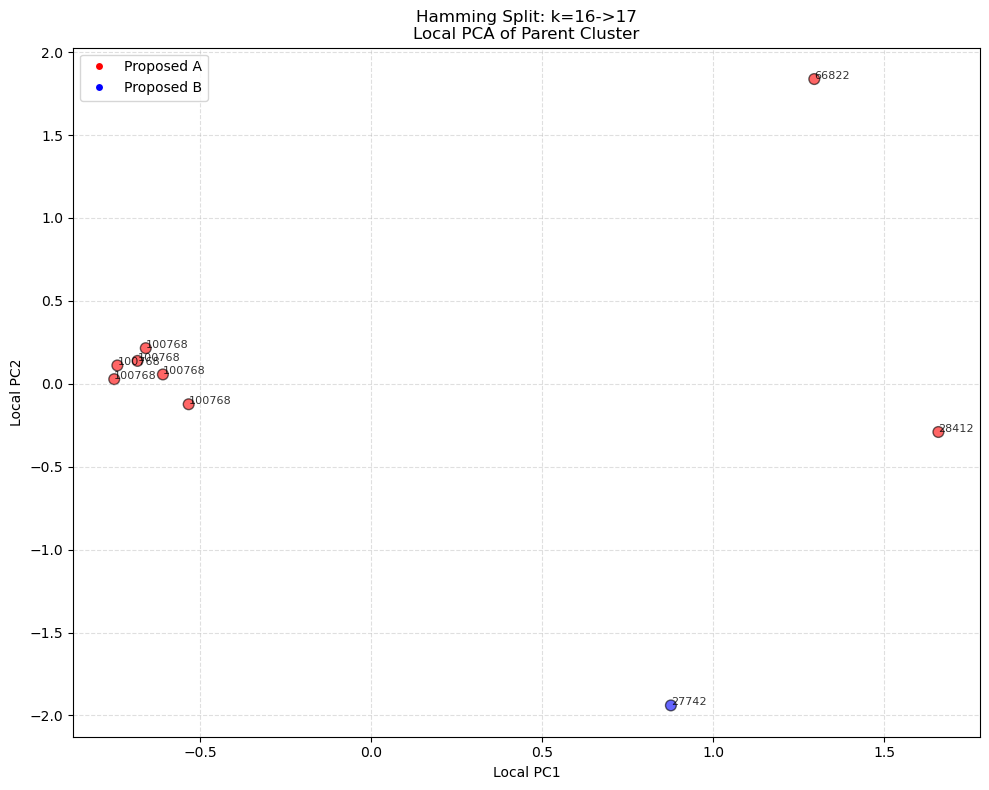

[DEBUG]    Calling validate_split_percentile()...
signal distance is 38.90802001953125
      [Val] Auto-Accept: Signal dist 38.9 < 15 & Length 48 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=17 justified.

[DEBUG] --- Iteration k=17 -> k=18 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


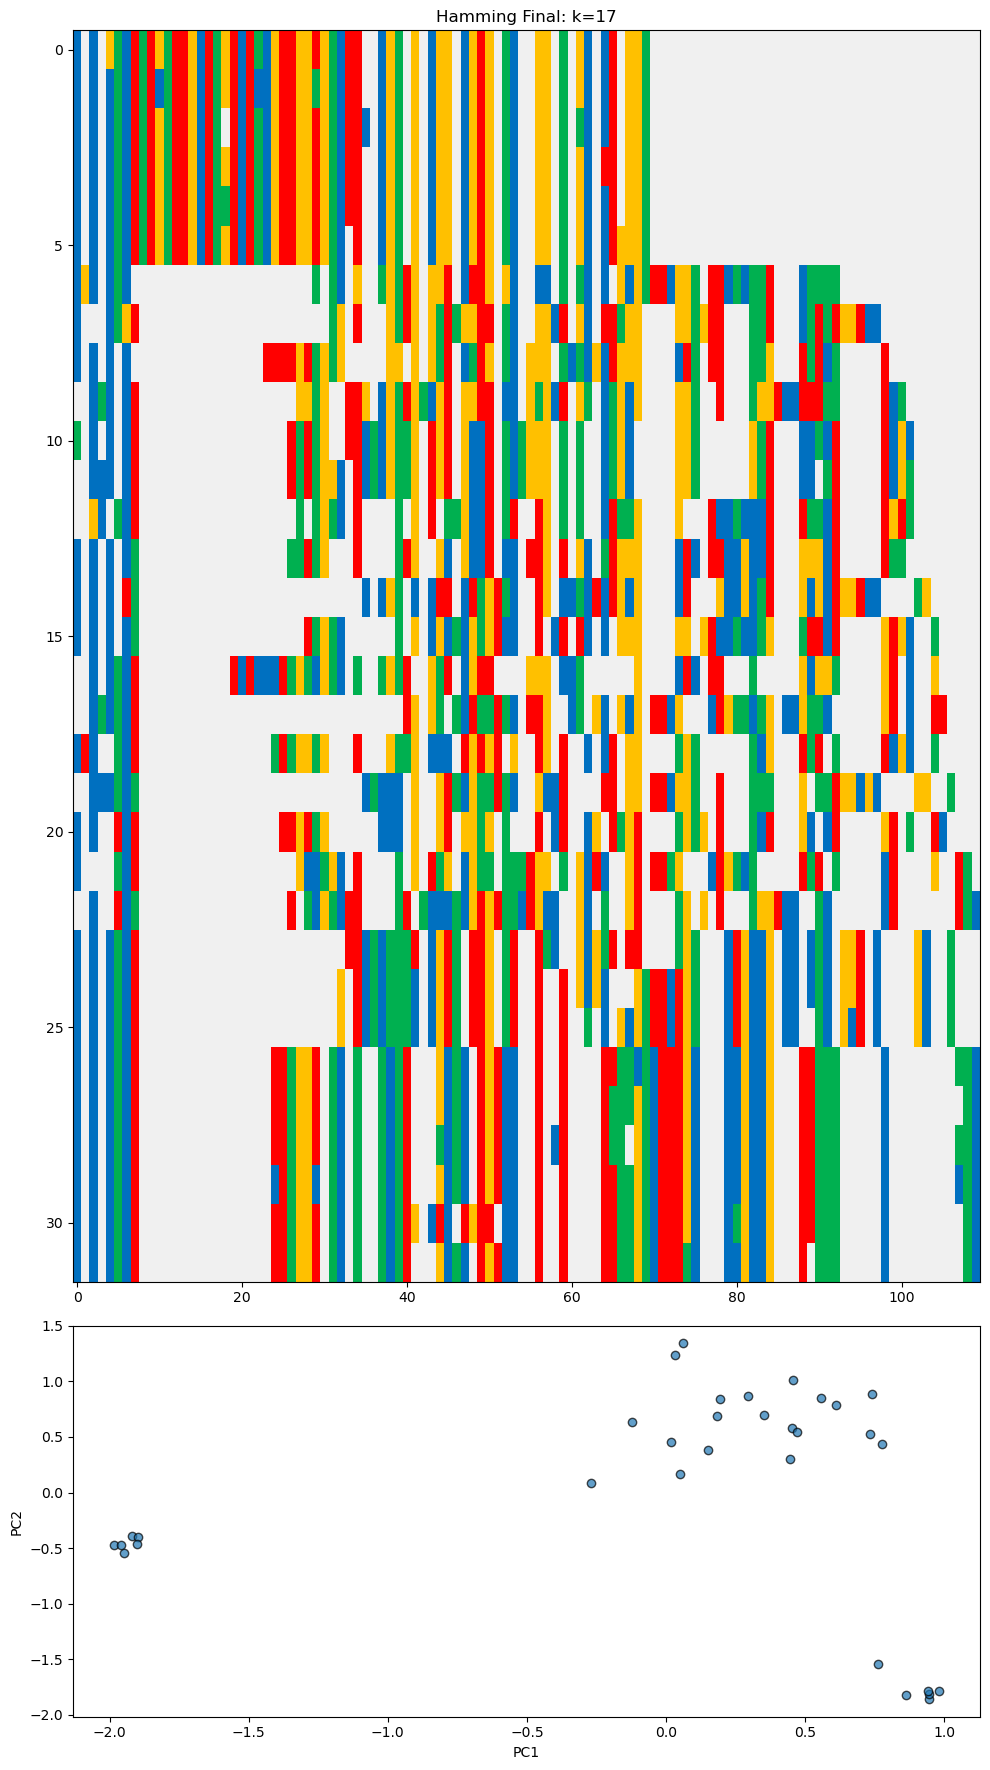

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=8) split into: [ 1  5 15]
[DEBUG]    Split Sizes: {1: 6, 5: 1, 15: 1}
    Checking split of Cluster 1 -> New sizes 6 vs 1
[DEBUG]    Generating plot for proposal...


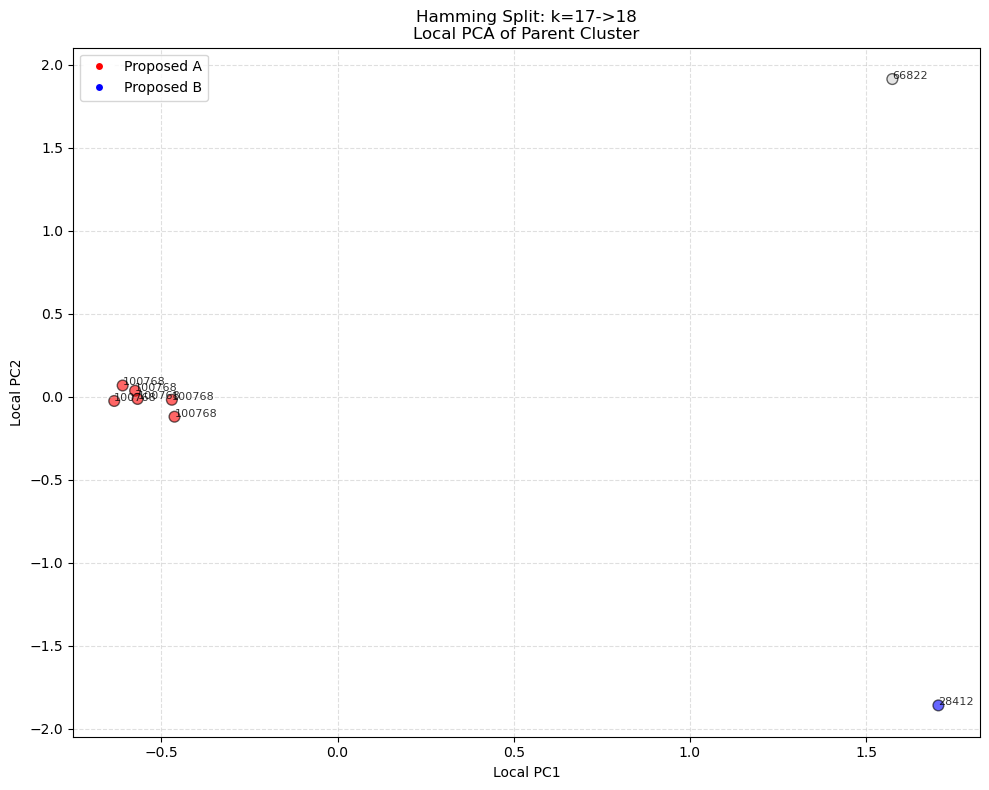

[DEBUG]    Calling validate_split_percentile()...
signal distance is 41.08171081542969
      [Val] Auto-Accept: Signal dist 41.1 < 15 & Length 51 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=18 justified.

[DEBUG] --- Iteration k=18 -> k=19 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


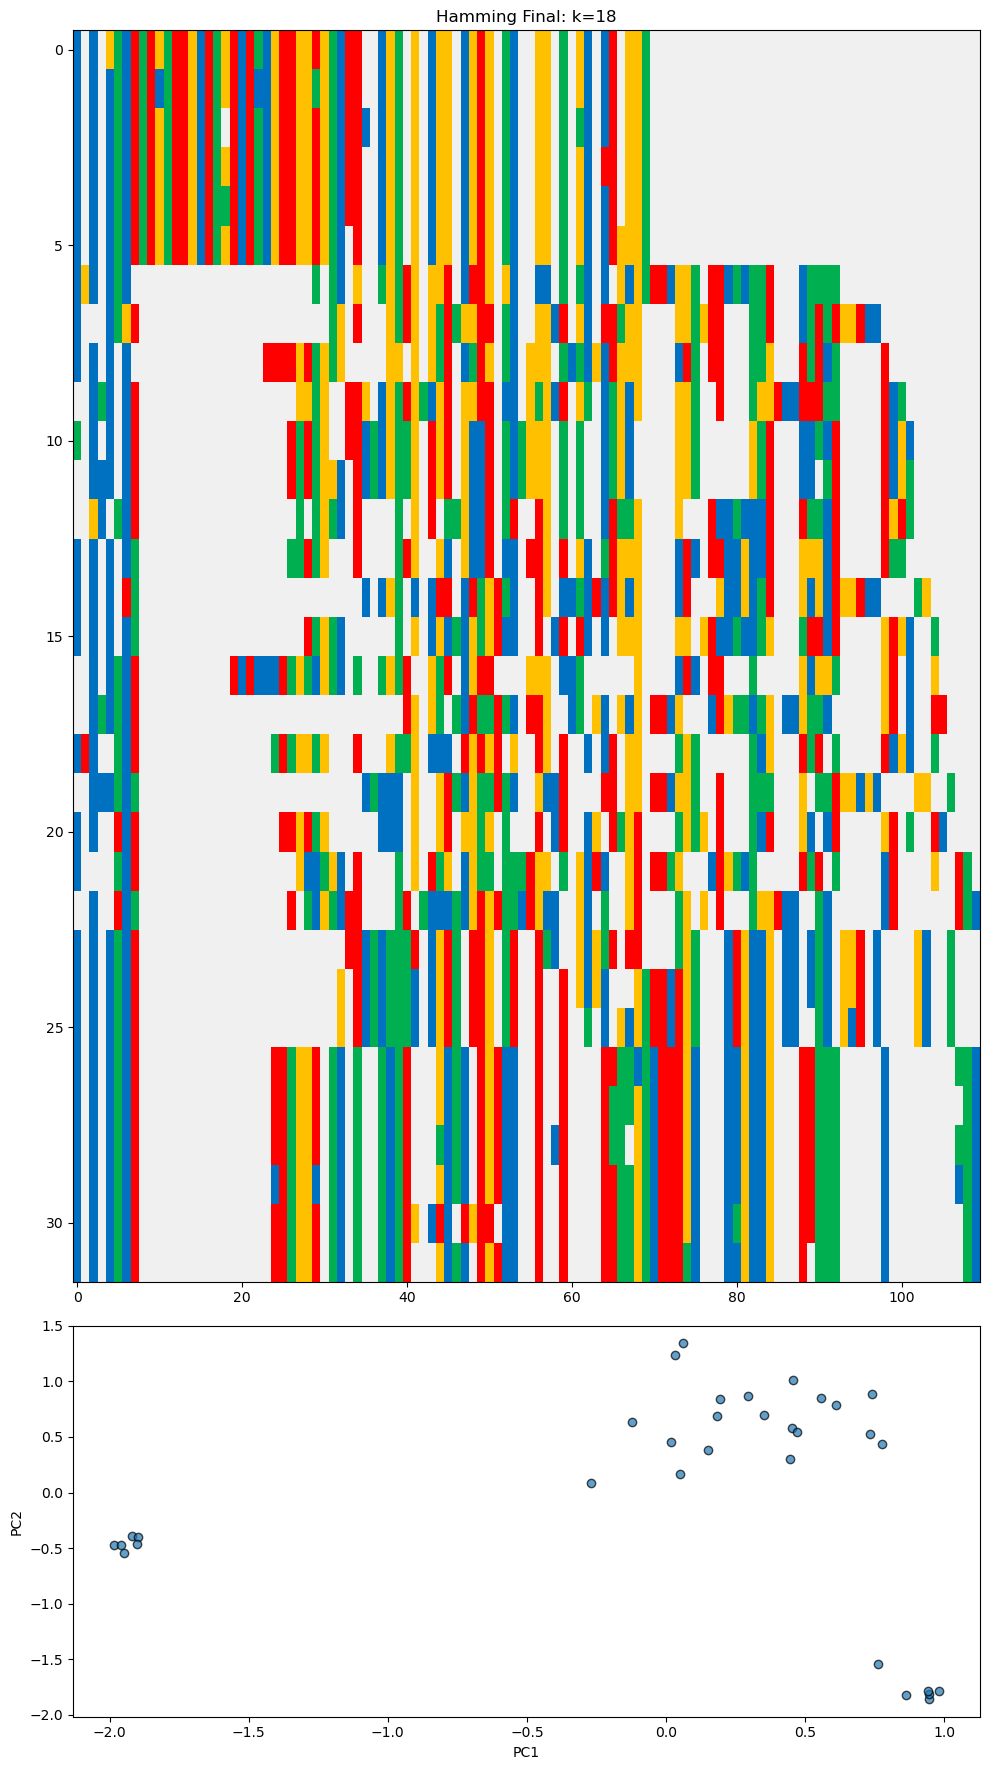

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=7) split into: [1 2]
[DEBUG]    Split Sizes: {1: 6, 2: 1}
    Checking split of Cluster 1 -> New sizes 6 vs 1
[DEBUG]    Generating plot for proposal...


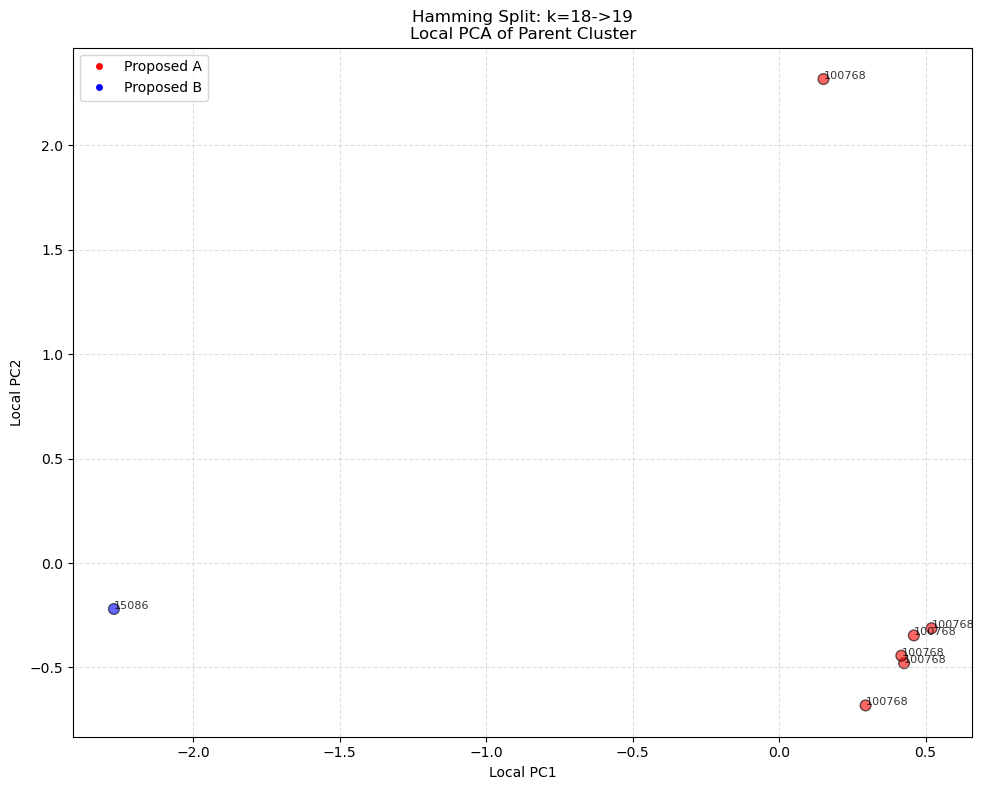

[DEBUG]    Calling validate_split_percentile()...
signal distance is 43.57200241088867
      [Val] Auto-Accept: Signal dist 43.6 < 15 & Length 51 > 30
[DEBUG]    >> VALIDATION PASSED. This split is real.
  -> Expansion to k=19 justified.

[DEBUG] --- Iteration k=19 -> k=20 ---
[DEBUG] Running AgglomerativeClustering (Hamming/Average)...
[[1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 [1 5 1 ... 5 5 5]
 ...
 [1 5 1 ... 1 0 1]
 [1 5 1 ... 5 0 1]
 [1 5 1 ... 5 0 1]]


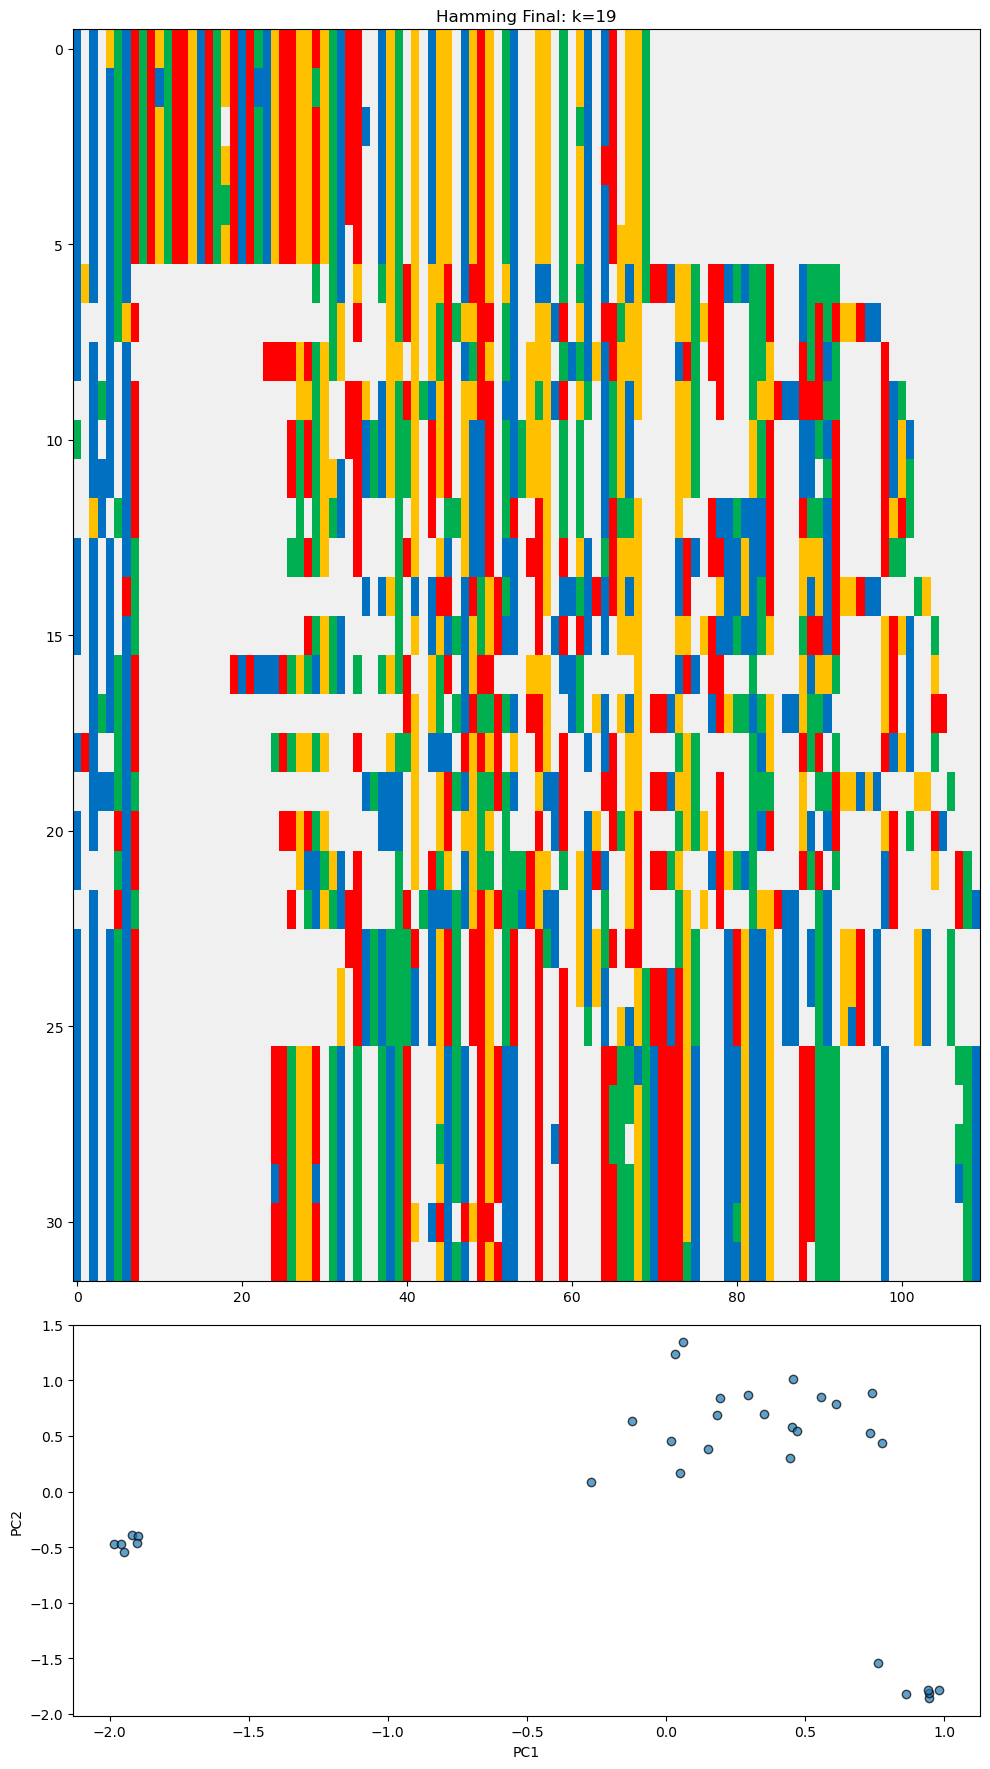

[DEBUG] Existing clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]. Checking which one split...
[DEBUG] >> Parent Cluster 1 (N=6) split into: [ 3 19]
[DEBUG]    Split Sizes: {3: 5, 19: 1}
    Checking split of Cluster 1 -> New sizes 5 vs 1
[DEBUG]    Generating plot for proposal...


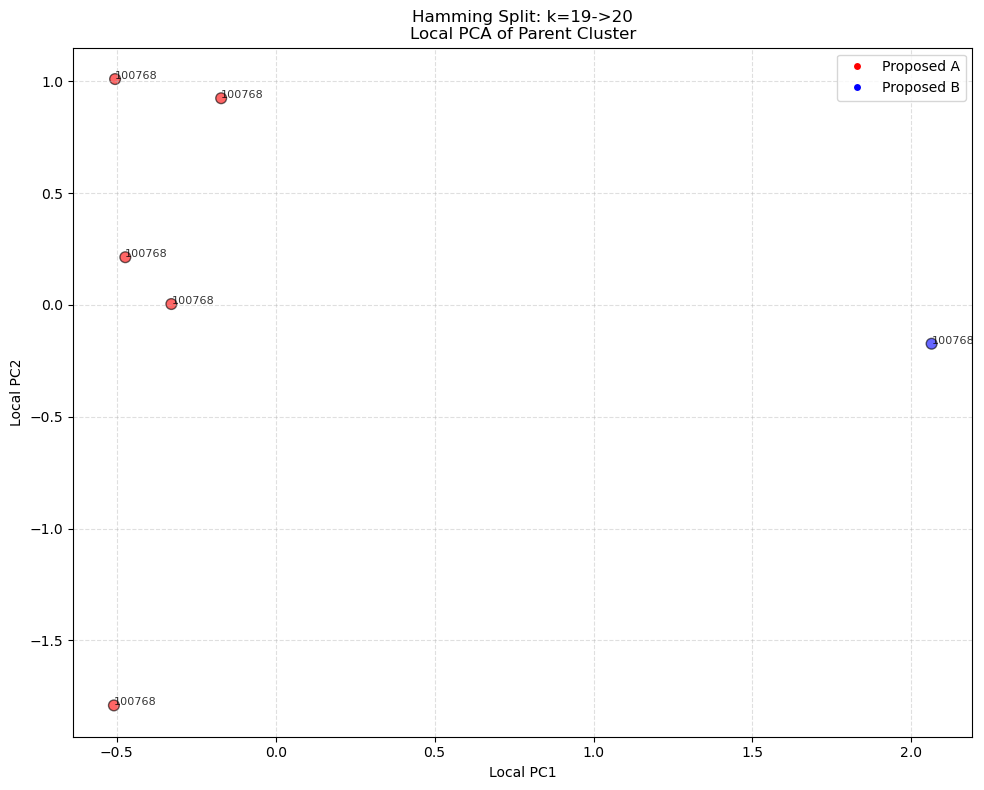

[DEBUG]    Calling validate_split_percentile()...
signal distance is 9.72093677520752
      [Val] Signal: 9.7 | BG Thresh: 34.7 | Valid: False
[[ 8.737862]
 [ 8.737862]
 [11.53846 ]
 [10.679611]
 [ 8.910889]]
[DEBUG]    >> VALIDATION FAILED. Ignoring this split.
  -> Expansion to k=20 rejected. Stopping.
[DEBUG] No valid splits found among any parent clusters for k=20.
[DEBUG] Returning 19 final clusters.
  > Final Clusters: 19
    Cluster 0: 6 reads, {268}
    Cluster 1: 6 reads, {100768}
    Cluster 2: 1 reads, {15086}
    Cluster 3: 3 reads, {100268}
    Cluster 4: 1 reads, {48184}
    Cluster 5: 1 reads, {71776}
    Cluster 6: 1 reads, {52474}
    Cluster 7: 1 reads, {26221}
    Cluster 8: 1 reads, {73703}
    Cluster 9: 1 reads, {66822}
    Cluster 10: 1 reads, {17873}
    Cluster 11: 1 reads, {55428}
    Cluster 12: 2 reads, {20257}
    Cluster 13: 1 reads, {44623}
    Cluster 14: 1 reads, {18667}
    Cluster 15: 1 reads, {28412}
    Cluster 16: 1 reads, {27742}
    Cluster 17: 1

In [8]:
# --- 5. EXECUTION LOOP ---

import pandas as pd
from typing import List

# Assume the previous code block ran and 'result_dfs' is populated.
# For demonstration purposes, we'll create a dummy 'result_dfs':
# --- Start Dummy Data ---
# Cluster 0: ID 'A' duplicated.
df0 = pd.DataFrame({'ID': ['A', 'B', 'A'], 'Read': ['r1', 'r2', 'r3']}) 
# Cluster 1: IDs 'C' and 'D'.
df1 = pd.DataFrame({'ID': ['C', 'D'], 'Read': ['r4', 'r5']}) 
# Cluster 2: Contains ID 'A', which is also in df0.
df2 = pd.DataFrame({'ID': ['E', 'A'], 'Read': ['r6', 'r7']}) 
result_dfs = [df0, df1, df2]
# --- End Dummy Data ---

# --- Actual Integrity Check Code ---

def check_cluster_id_integrity(result_dfs: List[pd.DataFrame], verbose=0):
    """
    Performs two critical checks on IDs within the clustered DataFrames:
    1. Checks for two or more IDs within a single cluster (DataFrame).
    2. Checks for the same ID across multiple clusters (DataFrames).
    """
    
    # 1. Check for Duplicate IDs WITHIN a single DataFrame/Cluster

    bad = False
        
    for df in result_dfs:
        if len(set(df['ID'])) > 1:
            if verbose >= 2:
                print("\n⚠️ WARNING (Type 1: Two IDs in 1 cluster) ⚠️")
                print(set(df['ID']))
            bad = True
    
    # 2. Check for the Same ID ACROSS multiple DataFrames/Clusters
    
    all_cluster_ids = {} # {id_value: [list_of_cluster_indices]}
    
    for j, df in enumerate(result_dfs):
        if 'ID' in df.columns:
            for id_value in df['ID'].unique():
                if id_value not in all_cluster_ids:
                    all_cluster_ids[id_value] = []
                all_cluster_ids[id_value].append(j)

    # Filter for IDs that appear in more than one cluster
    shared_ids = {
        id_value: clusters 
        for id_value, clusters in all_cluster_ids.items() 
        if len(clusters) > 1
    }

    if shared_ids:
        if verbose >= 2:
            print("\n⚠️ WARNING (Type 2: Inter-Cluster Overlap) ⚠️")
            for id_value, clusters in shared_ids.items():
                print(f"  > ID '{id_value}' is in Clusters: {clusters}")
        bad = True

    return bad



VERBOSE_LEVEL = 3
PERCENTILE_TH = 5  # LOWER = MORE SPLITTING

good_bad_d = {'good':0, 'bad': 0}

for i, (top_bc, count) in enumerate(barcode_counts.head(1).items()):
    verbose = VERBOSE_LEVEL
    if verbose >= 1:
        print(f"Processing Top Barcode #{i+1}: {top_bc} (Count: {count})")

    # top_bc = "TATCATGGCAGC" # Force specific barcode if needed for debug
    
    # RapidFuzz
    scores = process.cdist([top_bc], all_barcodes, scorer=fuzz.ratio, dtype=np.uint8)[0]
    candidate_bcs = all_barcodes[np.where(scores > 85)[0]]
    filtered_df = df[df['Barcode'].isin(candidate_bcs)].copy()

    # filtered_df = edge_case_df.copy()  # DEBUG

    if filtered_df.empty: continue
    
    if VERBOSE_LEVEL >= 2:
        print(f"  > RapidFuzz gathered {len(filtered_df)} reads")

    result_dfs = iterative_hamming_driver(filtered_df, df, top_bc, 
                                          percentile_th=PERCENTILE_TH, verbose=VERBOSE_LEVEL)

    if verbose >= 1:
        print(f"  > Final Clusters: {len(result_dfs)}")
        for j, c in enumerate(result_dfs):
            print(f"    Cluster {j}: {len(c)} reads, {set(c['ID'])}")

    # Execute the integrity checks
    bad = check_cluster_id_integrity(result_dfs, verbose=VERBOSE_LEVEL)
    if bad:
        good_bad_d['bad'] += 1
    else:
        good_bad_d['good'] += 1

    assert not bad

print(good_bad_d)




In [11]:
for r in result_dfs:
    print(r)



           ID        Barcode  \
1637      471   TATCATGGCAGC   
1638      471   TATCATGGCAGC   
1639      471   TATCATGGCAGC   
1640      471   TATCATGGCAGC   
1641      471   TATCATGGCAGC   
1642      471   TATCATGGCAGC   
6914     1996    TGATCATGCGC   
107388  30579    TATCAAGGCAC   
111140  31652  TTCATGGCCAGCC   

                                                   Insert  
1637    AAAAGTTCGTCGCTTATACCTGGAAATATTAGGCGAAACATCCCGA...  
1638    AAATAGTTGTCGCTTATACCTGAATATTAGGAGAACATCCCGACCA...  
1639    AAAAGTTGTCGCTTATACCTGAATATTAGGCGAACATCCCGACCAA...  
1640    AAAAGTTGTCGCTTATACCTGAATATTAGGCGAACATCCCGACCAA...  
1641    AACAAGTTGTCGCTTATACCTGAATTTGAGGCGACATCCCGACCAA...  
1642    AAAAGTTGTCGCGTATACCTGAATATTAGGCGAACATCCCGACCAT...  
6914    CCTCATCTGAAGGCATTCTTAAAGTGGCCACGTCCACAGGCTACCC...  
107388  CTTCGGGCTTCGTGCGACATTGTCCGGAAGCCGTCGTAATTTTACG...  
111140  ACAGTCGACGGCACCCTATAAGAACTAATTCCACTCGCGTCCCCCT...  
          ID        Barcode                                             Insert


In [266]:
import pandas as pd

# 1. Create the base DataFrame
data = {
    'ID': [2787, 4536, 4536],
    'Barcode': ['TGCGCGTTCCCCG', 'TCGGCTCCCAG', 'TCAGGCTCCCCAG'],
    'Insert': ['ATAATGTACCCCTTAACCTGAAGAAGGATGCCTCGGCGACGGGGATTCGTA', 
               'ATTTAGAGCTCCCCACCTTCAAGAACTCACGGGAGCAGAAGATGATCGCA',
    'ATTTAGAGCTGCCCACCTTCAAGAACTCAGGGAGCAGAAGATGTATCGCA']
}

df = pd.DataFrame(data)

# 2. Duplicate it 10 times
edge_case_df = pd.concat([df] * 1)


In [228]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

# Your matrix
X = np.array([
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 0, 1, 1, 0, 1, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 1, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [3, 1, 1, 1, 0, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 1, 2, 5], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [5, 1, 1, 1, 0, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 5, 1, 1, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [0, 1, 1, 5, 0, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [3, 3, 5, 0, 3, 1, 2, 2, 5], # <-- TARGET CLUSTER
 [3, 3, 5, 0, 3, 1, 2, 2, 5], # <-- TARGET CLUSTER
 [3, 3, 5, 0, 3, 1, 2, 2, 5]  # <-- TARGET CLUSTER
])

# Use Agglomerative Clustering with Hamming Distance
# distance_threshold=0.3 means "Separate clusters if their sequences differ by more than 30%"
model = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=0.2,  
    metric='hamming', 
    linkage='average'
)

labels = model.fit_predict(X)

print(f"Clusters Found: {len(np.unique(labels))}")
print("-" * 30)
for lbl in np.unique(labels):
    indices = np.where(labels == lbl)[0]
    print(f"Cluster {lbl}: {len(indices)} items (Indices: {indices})")

Clusters Found: 6
------------------------------
Cluster 0: 26 items (Indices: [ 0  1  2  3  4  5  6  7  9 10 11 12 14 15 16 17 18 19 20 22 23 24 25 26
 28 29])
Cluster 1: 3 items (Indices: [30 31 32])
Cluster 2: 1 items (Indices: [27])
Cluster 3: 1 items (Indices: [21])
Cluster 4: 1 items (Indices: [8])
Cluster 5: 1 items (Indices: [13])


/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


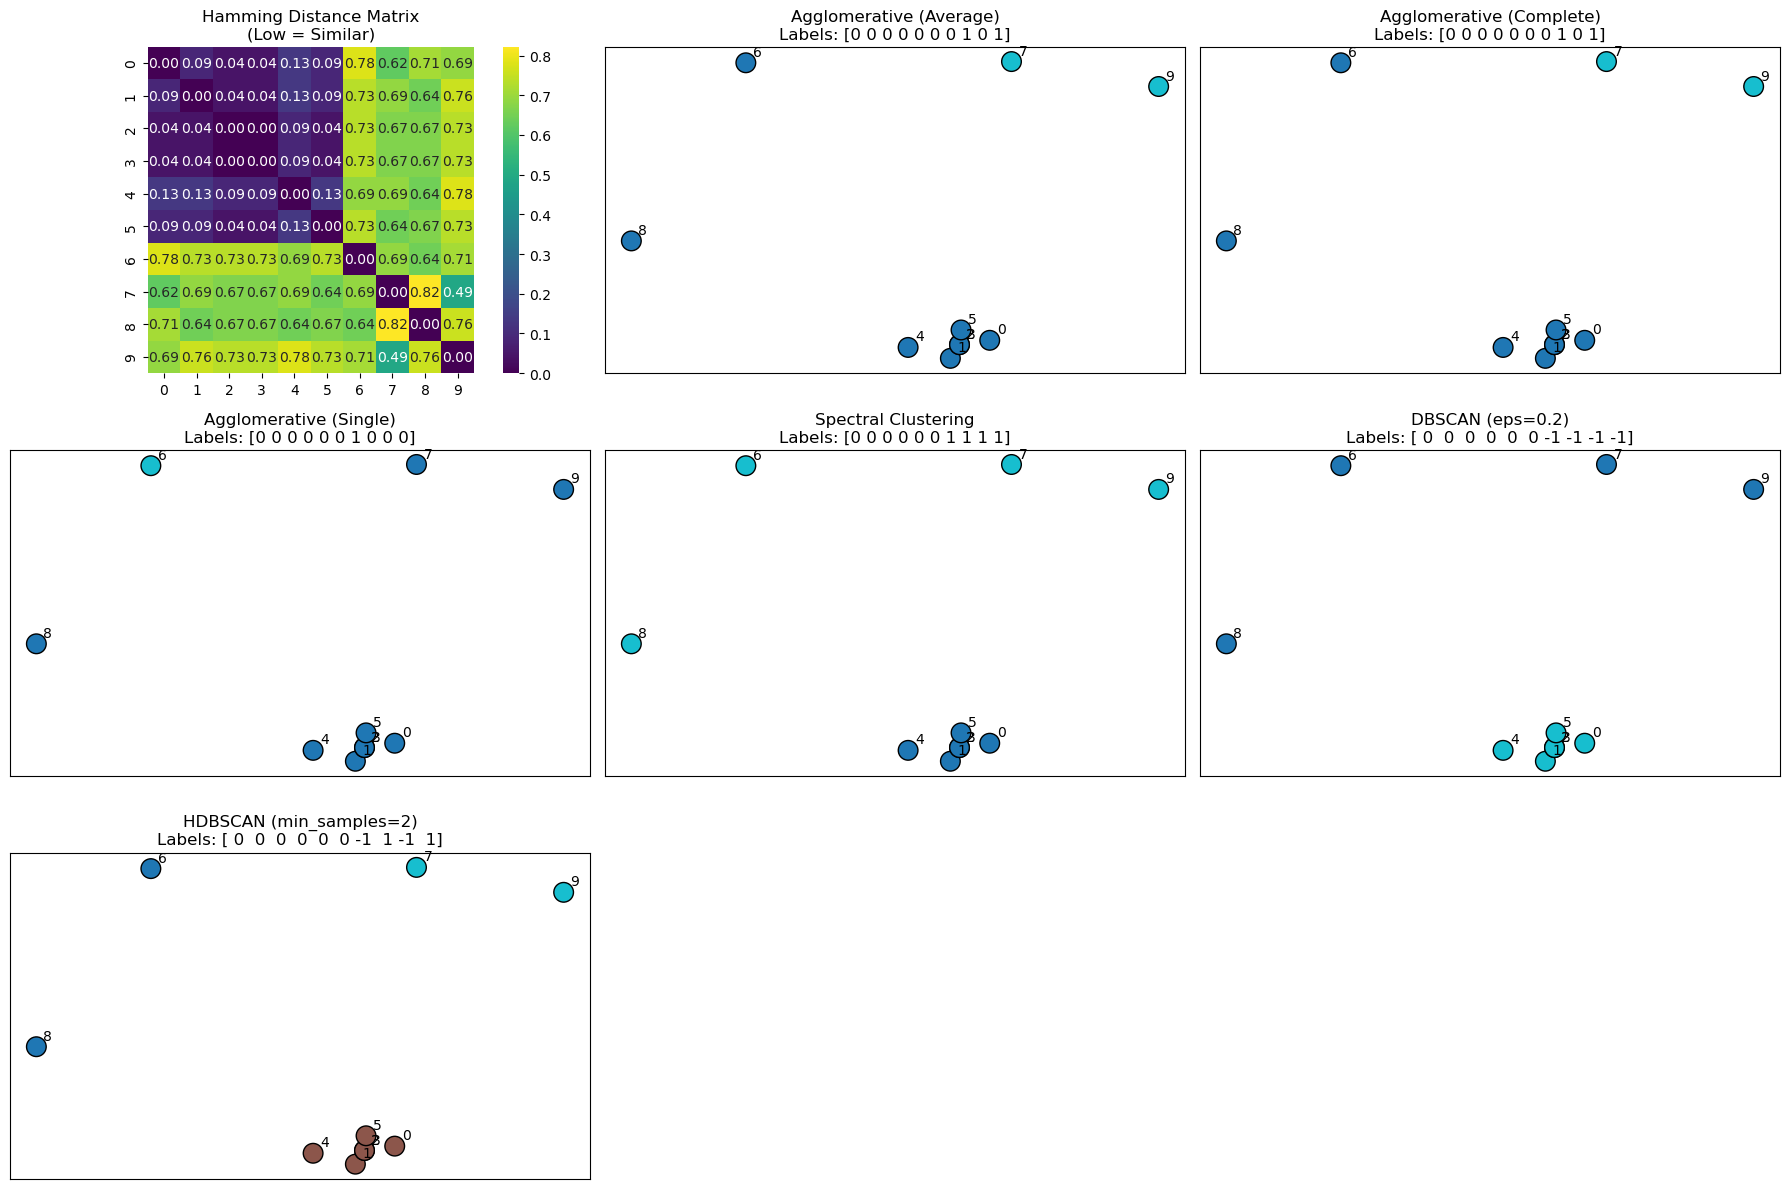

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, HDBSCAN
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import pairwise_distances

# 1. THE DATA (Your sample matrix)
matrix = np.array([
 [5, 2, 2, 0, 0, 5, 0, 5, 5, 0, 2, 3, 3, 1, 1, 3, 3, 0, 1, 2, 2, 0, 3, 0, 3, 3, 0, 1, 0, 0, 0, 1, 5, 1, 2, 0, 1, 0, 0, 1, 1, 0, 5, 5, 5],
 [5, 2, 2, 0, 0, 5, 0, 3, 5, 0, 2, 3, 3, 1, 1, 3, 3, 0, 1, 2, 5, 5, 3, 0, 3, 3, 0, 0, 0, 0, 0, 1, 5, 1, 2, 0, 1, 0, 0, 1, 1, 0, 5, 5, 5],
 [5, 2, 2, 0, 0, 5, 0, 5, 5, 0, 2, 3, 3, 1, 1, 3, 3, 0, 1, 2, 5, 5, 3, 0, 3, 3, 0, 1, 0, 0, 0, 1, 5, 1, 2, 0, 1, 0, 0, 1, 1, 0, 5, 5, 5],
 [5, 2, 2, 0, 0, 5, 0, 5, 5, 0, 2, 3, 3, 1, 1, 3, 3, 0, 1, 2, 5, 5, 3, 0, 3, 3, 0, 1, 0, 0, 0, 1, 5, 1, 2, 0, 1, 0, 0, 1, 1, 0, 5, 5, 5],
 [5, 2, 2, 0, 0, 1, 0, 5, 5, 0, 2, 3, 3, 1, 1, 3, 3, 0, 1, 2, 5, 5, 3, 3, 3, 2, 0, 1, 5, 0, 0, 1, 5, 1, 2, 0, 1, 0, 0, 1, 1, 0, 5, 5, 5],
 [5, 2, 2, 0, 0, 5, 0, 5, 5, 0, 2, 3, 3, 1, 1, 2, 3, 0, 1, 2, 5, 5, 3, 0, 3, 3, 0, 1, 0, 0, 0, 1, 5, 1, 2, 0, 1, 0, 3, 1, 1, 0, 5, 5, 5],
 [2, 5, 2, 5, 5, 1, 1, 3, 1, 0, 3, 1, 0, 0, 5, 2, 1, 5, 3, 3, 5, 5, 5, 0, 5, 2, 3, 1, 5, 0, 2, 1, 0, 1, 0, 2, 2, 3, 0, 1, 1, 1, 2, 2, 0],
 [5, 2, 2, 5, 5, 5, 5, 5, 5, 5, 5, 1, 3, 1, 0, 2, 5, 1, 2, 2, 2, 0, 2, 3, 1, 0, 0, 5, 0, 3, 2, 2, 5, 1, 0, 2, 2, 0, 2, 3, 1, 1, 2, 2, 1],
 [5, 2, 5, 3, 3, 1, 1, 3, 1, 5, 1, 3, 3, 5, 5, 3, 1, 0, 0, 3, 5, 5, 5, 1, 5, 1, 3, 3, 1, 0, 0, 1, 5, 5, 5, 0, 1, 0, 3, 2, 2, 1, 1, 2, 2],
 [5, 2, 5, 5, 5, 5, 5, 5, 5, 5, 1, 3, 5, 5, 5, 2, 1, 1, 2, 2, 2, 0, 3, 3, 2, 3, 1, 5, 0, 1, 2, 2, 3, 0, 0, 3, 3, 3, 0, 1, 2, 2, 2, 2, 0]
])

# Settings
N_CLUSTERS = 2  
dist_matrix = pairwise_distances(matrix, metric='hamming')
affinity_matrix = 1 - dist_matrix

# 2. SETUP VISUALIZATION
# Increased size to fit more plots
fig = plt.figure(figsize=(18, 12)) 

# --- Plot 1: The Distance Heatmap ---
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(dist_matrix, annot=True, fmt=".2f", cmap="viridis", ax=ax1, square=True)
ax1.set_title("Hamming Distance Matrix\n(Low = Similar)")

# --- Prepare 2D Projection (MDS) ---
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords = mds.fit_transform(dist_matrix)

# 3. DEFINE ALGORITHMS
# Note: DBSCAN/HDBSCAN labels of '-1' mean "Noise" (Outlier)
algorithms = [
    # Hierarchical
    ("Agglomerative (Average)", AgglomerativeClustering(n_clusters=N_CLUSTERS, metric='precomputed', linkage='average')),
    ("Agglomerative (Complete)", AgglomerativeClustering(n_clusters=N_CLUSTERS, metric='precomputed', linkage='complete')),
    ("Agglomerative (Single)", AgglomerativeClustering(n_clusters=N_CLUSTERS, metric='precomputed', linkage='single')),
    
    # Graph-based
    ("Spectral Clustering", SpectralClustering(n_clusters=N_CLUSTERS, affinity='precomputed', random_state=42)),
    
    # Density-based (Note: Metric must be passed, 'precomputed' supported)
    # eps=0.2 means max distance of 20% mismatch to be considered a neighbor
    ("DBSCAN (eps=0.2)", DBSCAN(eps=0.2, min_samples=2, metric='precomputed')),
    
    # Hierarchical Density
    # HDBSCAN usually takes 'precomputed' distance matrix
    ("HDBSCAN (min_samples=2)", HDBSCAN(metric='precomputed', min_samples=2, min_cluster_size=2, allow_single_cluster=True))
]

# 4. LOOP AND PLOT
plot_idx = 2
for name, model in algorithms:
    ax = plt.subplot(3, 3, plot_idx)
    
    # Fit model
    if "Spectral" in name:
        labels = model.fit_predict(affinity_matrix)
    else:
        labels = model.fit_predict(dist_matrix)
        
    # Scatter plot
    # Using 'tab10' for distinct categories
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=200, edgecolors='k')
    
    # Label the points
    for i, txt in enumerate(range(len(matrix))):
        ax.annotate(txt, (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords='offset points')

    ax.set_title(f"{name}\nLabels: {labels}")
    ax.set_xticks([])
    ax.set_yticks([])
    plot_idx += 1

plt.tight_layout()
plt.show()

[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 2
 2 2 2 2 2]


NameError: name 'labels' is not defined

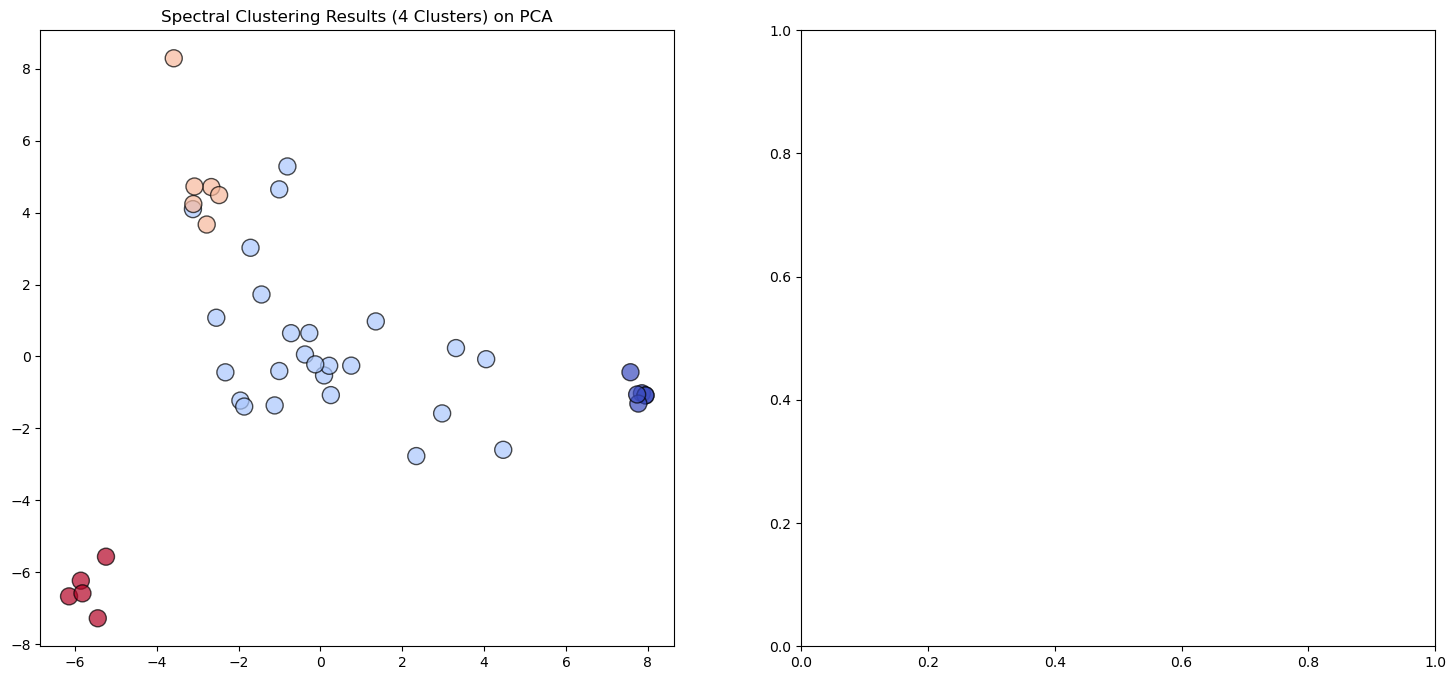

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
import numpy as np

msa_subset = np.load("/Users/ogw/Downloads/msa.npy")


next_k = 4 # Assuming this is the desired number of clusters
# ----------------------------------------------------------------------

### 1. Clustering
dist_matrix = pairwise_distances(msa_subset, metric='hamming')
affinity_matrix = 1 - dist_matrix

model_next = SpectralClustering(
    n_clusters=next_k,
    affinity='precomputed',
    random_state=42
)
next_labels = model_next.fit_predict(affinity_matrix)

print(next_labels)

### 2. Dimensionality Reduction (PCA)
# PCA requires feature scaling (standardization) before application,
# especially when working with raw integer counts or values.
from sklearn.preprocessing import StandardScaler

# Standardize the data (mean=0, variance=1)
scaler = StandardScaler()
msa_scaled = scaler.fit_transform(msa_subset)

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
principal_components = pca.fit_transform(msa_scaled)

# Create a DataFrame-like structure for plotting
pca_df = np.column_stack((principal_components, next_labels))


### 3. Plotting the Results
# --- Assuming 'next_labels' are your Spectral Clustering results
# --- Assuming 'labels' is your ground truth NumPy array (e.g., labels = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1]))

# Prepare data for plotting
pca_x = principal_components[:, 0]
pca_y = principal_components[:, 1]
row_indices = np.arange(len(msa_subset)) # For annotations

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))



# --- PLOT 1: Clustering Results (next_labels) ---
ax1.scatter(
    pca_x, 
    pca_y,
    c=next_labels,  # Uses the algorithm's labels
    cmap='coolwarm',
    s=150,
    edgecolors='k',
    alpha=0.7
)
ax1.set_title(f'Spectral Clustering Results ({next_k} Clusters) on PCA')

# --- PLOT 2: Ground Truth (labels) ---
# NOTE: Ensure 'labels' is correctly defined as a NumPy array of integers.
scatter2 = ax2.scatter(
    pca_x, 
    pca_y,
    c=labels,  # Uses the ground truth labels
    cmap='coolwarm',
    s=150,
    edgecolors='k',
    alpha=0.7
)
ax2.set_title(f'Ground Truth Labels on PCA')


# --- Standard Plot Formatting (Applied to both) ---
for ax in [ax1, ax2]:
    ax.set_xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}%)')
    ax.set_ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}%)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Annotate row indices on both plots
    for i, (x, y) in enumerate(zip(pca_x, pca_y)):
        ax.annotate(
            str(row_indices[i]),
            (x, y),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            color='black'
        )

# Add a single color bar/legend for clarity (optional, but helpful)
legend_elements = scatter2.legend_elements()
fig.legend(legend_elements[0], legend_elements[1], title="Cluster/True Group", loc='lower center', ncol=next_k)

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust layout to make room for legend
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Identify the unique classes in each set independently
true_classes = np.unique(labels)       # e.g., [10, 20]
pred_classes = np.unique(next_labels)  # e.g., [0, 1]

# 2. Compute matrix using strict row/col definitions
# This prevents the "Union of all labels" explosion
cm = confusion_matrix(labels, next_labels, labels=None)

# We must slice/reorder the matrix if confusion_matrix didn't see all labels,
# but the safest way is to compute it manually or map it if the sets are totally disjoint.
# Ideally, sklearn's confusion_matrix handles mixed types if you don't provide the 'labels' arg,
# but to be safe and explicit:
cm = np.zeros((len(true_classes), len(pred_classes)), dtype=int)
for i, true_label in enumerate(true_classes):
    for j, pred_label in enumerate(pred_classes):
        # Count intersections
        cm[i, j] = np.sum((labels == true_label) & (next_labels == pred_label))

# 3. Plot
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    square=True, # Keeps cells square, not the whole plot
    xticklabels=pred_classes,
    yticklabels=true_classes
)

# 4. Invert Y-Axis (Put the lowest label at the bottom)
ax.invert_yaxis()

plt.ylabel('Ground Truth Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Cluster Label', fontsize=12, fontweight='bold')
plt.title('Cluster Assignment Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

[ 5  5  5  5  5  5  5  6 -1 -1  4 -1  2  3  3  6  3  2 -1 -1  4 -1 -1 -1
 -1 -1  1  1 -1 -1 -1  1  1  1  1  1  0  0  0  0  0  0]


/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


NameError: name 'labels' is not defined

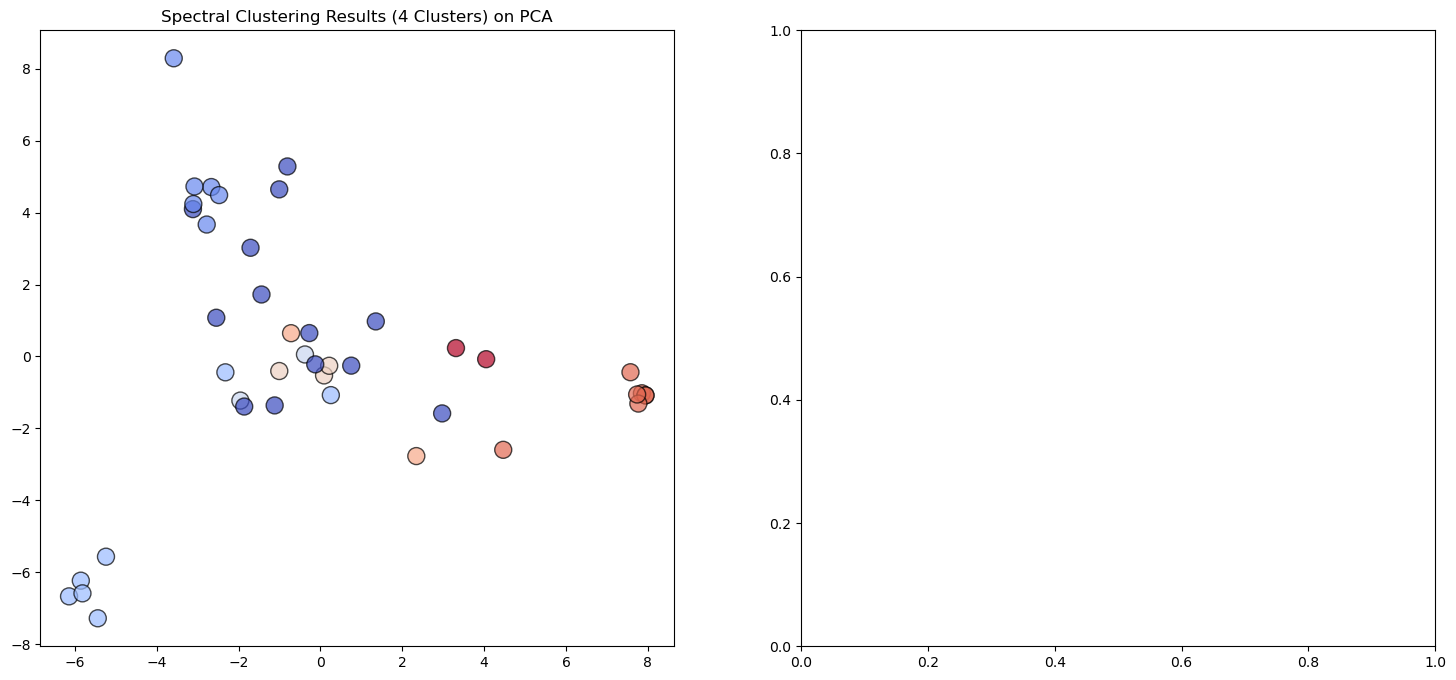

In [5]:
msa_subset = np.load("/Users/ogw/Downloads/msa.npy")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN

next_k = 4 # Assuming this is the desired number of clusters
# ----------------------------------------------------------------------

### 1. Clustering
### 1. Clustering
# HDBSCAN requires the DISTANCE matrix (not affinity)
dist_matrix = pairwise_distances(msa_subset, metric='hamming')

# NOTE: affinity_matrix is no longer needed for HDBSCAN, but you can keep 
# the line if needed for other code downstream.
# affinity_matrix = 1 - dist_matrix 

# 2. Run HDBSCAN on the distance matrix
# Parameters: 'min_cluster_size' and 'min_samples' replace n_clusters (k).
# We use small values here as your dataset is tiny (10 points).
model_next = HDBSCAN(
    metric='precomputed',
    min_cluster_size=2, 
    min_samples=2
)

# HDBSCAN fits directly on the distance matrix
next_labels = model_next.fit_predict(dist_matrix)

print(next_labels)
### 2. Dimensionality Reduction (PCA)
# PCA requires feature scaling (standardization) before application,
# especially when working with raw integer counts or values.
from sklearn.preprocessing import StandardScaler

# Standardize the data (mean=0, variance=1)
scaler = StandardScaler()
msa_scaled = scaler.fit_transform(msa_subset)

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
principal_components = pca.fit_transform(msa_scaled)

# Create a DataFrame-like structure for plotting
pca_df = np.column_stack((principal_components, next_labels))


### 3. Plotting the Results
# --- Assuming 'next_labels' are your Spectral Clustering results
# --- Assuming 'labels' is your ground truth NumPy array (e.g., labels = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1]))

# Prepare data for plotting
pca_x = principal_components[:, 0]
pca_y = principal_components[:, 1]
row_indices = np.arange(len(msa_subset)) # For annotations

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))



# --- PLOT 1: Clustering Results (next_labels) ---
ax1.scatter(
    pca_x, 
    pca_y,
    c=next_labels,  # Uses the algorithm's labels
    cmap='coolwarm',
    s=150,
    edgecolors='k',
    alpha=0.7
)
ax1.set_title(f'Spectral Clustering Results ({next_k} Clusters) on PCA')

# --- PLOT 2: Ground Truth (labels) ---
# NOTE: Ensure 'labels' is correctly defined as a NumPy array of integers.
scatter2 = ax2.scatter(
    pca_x, 
    pca_y,
    c=labels,  # Uses the ground truth labels
    cmap='coolwarm',
    s=150,
    edgecolors='k',
    alpha=0.7
)
ax2.set_title(f'Ground Truth Labels on PCA')


# --- Standard Plot Formatting (Applied to both) ---
for ax in [ax1, ax2]:
    ax.set_xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}%)')
    ax.set_ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}%)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Annotate row indices on both plots
    for i, (x, y) in enumerate(zip(pca_x, pca_y)):
        ax.annotate(
            str(row_indices[i]),
            (x, y),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            color='black'
        )

# Add a single color bar/legend for clarity (optional, but helpful)
legend_elements = scatter2.legend_elements()
fig.legend(legend_elements[0], legend_elements[1], title="Cluster/True Group", loc='lower center', ncol=next_k)

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust layout to make room for legend
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Identify the unique classes in each set independently
true_classes = np.unique(labels)       # e.g., [10, 20]
pred_classes = np.unique(next_labels)  # e.g., [0, 1]

# 2. Compute matrix using strict row/col definitions
# This prevents the "Union of all labels" explosion
cm = confusion_matrix(labels, next_labels, labels=None)

# We must slice/reorder the matrix if confusion_matrix didn't see all labels,
# but the safest way is to compute it manually or map it if the sets are totally disjoint.
# Ideally, sklearn's confusion_matrix handles mixed types if you don't provide the 'labels' arg,
# but to be safe and explicit:
cm = np.zeros((len(true_classes), len(pred_classes)), dtype=int)
for i, true_label in enumerate(true_classes):
    for j, pred_label in enumerate(pred_classes):
        # Count intersections
        cm[i, j] = np.sum((labels == true_label) & (next_labels == pred_label))

# 3. Plot
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    square=True, # Keeps cells square, not the whole plot
    xticklabels=pred_classes,
    yticklabels=true_classes
)

# 4. Invert Y-Axis (Put the lowest label at the bottom)
ax.invert_yaxis()

plt.ylabel('Ground Truth Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Cluster Label', fontsize=12, fontweight='bold')
plt.title('Cluster Assignment Heatmap', fontsize=14)
plt.tight_layout()
plt.show()